# Rollator stability-envelope geometry

Exploration + thesis-figure notebook. Figures render inline at thesis quality, nothing is
written to disk (no `savefig`, no PDF/PNG export), no LaTeX emitted, tables just print as
plain text.

## The four shape coordinates

The dynamic tipping envelope is bounded by two lines in the (F_x, F_z) plane, both affine in F_z:

```
    F_x,r(F_z) = a_r + b_r * F_z      rear  / backward-tipping boundary, a_x = +a_max   Eq. (16)
    F_x,f(F_z) = a_f + b_f * F_z      front / forward-tipping  boundary, a_x = -a_max   Eq. (17)
```

Instead of the four raw line parameters (a_r, b_r, a_f, b_f), four named shape coordinates
are used, each isolating one geometric effect on the envelope trapezoid:

| name | what it does to the trapezoid | in terms of the line parameters |
|---|---|---|
| **Translation** | shifts the whole trapezoid left/right | mean intercept, (a_r + a_f) / 2 |
| **Shear**       | tilts both edges by the same amount   | mean slope,     (b_r + b_f) / 2 |
| **Base separation** | widens/narrows the trapezoid at F_z = 0 | intercept difference, a_r - a_f |
| **Flare**       | splays the edges apart as F_z rises    | slope difference,     b_r - b_f |

(these names are what's used everywhere below, including on every figure)

Dynamic stability capacity, an identity in the same coordinates:

```
    Psi = (Base separation) * F_z,max  +  1/2 * (Flare) * F_z,max^2
```

## Notation

Wheelbase parameterized by the rear axle position and wheelbase length (Ackermann & Mombaur
convention, origin `O` under the handle, `x` toward the front):

* `X_r` - rear axle position relative to `O`, `X_r < 0` (rear axle behind the handle origin)
* `L` - wheelbase length, front axle derived as `X_f = X_r + L` (so `L > 0` and, for a valid
  geometry, `L > |X_r|` -> `X_f > 0`)

Other symbols: `X_cm, Z_cm` CoM fore/aft & height, `H` handle height, `m_r` mass, `theta`
incline, `a_max` |a_x| bound, `F_z,max` vertical-force ceiling, `c_rr` rolling resistance
(inert in the prescribed-`a_x` model, enters only in the F_drive=0 side note, 4.9).

Baseline (fixed, final design per thesis Table A.1, updated 2026-09-21):
`L = 1.200`, `Z_cm = 0.259840`, `H = 1.075`, `m_r = 32.964`, `theta = 0`, `F_z,max = 300`,
`X_cm = -0.370`, `X_r = -0.850` -> `X_f = +0.350` (handle sits behind the wheelbase midpoint,
at `X_r + L/2 = -0.250`, not centred). `a_max = 1.5 m/s^2` is still PROVISIONAL, pending
sign-off (per `parameter_sensitivity_sweeps.m`) - that label is carried through every output
below.

Boundary equations are the Eq. (16)-(17) family from `stability_envelope_thesis.m`
(`fxBack` / `fxForw` at a_x = +/-a_max), in the `(X_r, L)` wheelbase parametrization.


## 1. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.float_format", lambda v: f"{v: .6g}")
pd.set_option("display.width", 150)

# Thesis-figure styling (applies to every plot in this notebook).
plt.rcParams.update({
    "figure.dpi":        120,
    "font.size":         11,
    "axes.titlesize":    12,
    "axes.labelsize":    11,
    "legend.fontsize":   9,
    "axes.grid":         True,
    "grid.alpha":        0.25,
    "axes.axisbelow":    True,
    "figure.facecolor":  "white",
    "axes.facecolor":    "white",
})

# fixed baseline parameters, final design (Table A.1 of the thesis), not swept.
#   Updated 2026-09-21 to the final design: m_r, X_cm, Z_cm moved from the pre-optimization
#   ("Parameter Study" chapter) values to the Stage 1-3 optimized final values. NOTE: this
#   means the %/N^2 figures already written into the thesis's Chapter 3/4 prose (e.g. "+10cm
#   wheelbase -> +8.59% Psi", "+1kg mass -> +2.79% Psi", "2784.8-3517.6 N^2 depending on H")
#   were computed against the OLD baseline (m_r=19.624, Z_cm=0.211, X_cm=0) and will differ
#   from what this notebook now prints, see the chat summary for the new numbers to quote.
#   L      = 1.200 m   wheelbase length (final design)
#   Z_cm   = 0.259840 m   CoM height (final design, Table A.1; Table 4.1 rounds this to 0.25)
#   H      = 1.075 m   handle height (Front Open handle-height requirement 0.95-1.20 m,
#                      elbow-height criterion [31], 63% of stature 150-191 cm; 1.075 m
#                      is the baseline within that range, not an "R16" standard, that
#                      earlier comment was a mislabel)
#   m_r    = 32.964 kg   final design mass (Table A.1; derived from Stage 1's mass increase)
#   theta  = 0        level ground (design stages executed at theta=0; the thesis notes the
#                      10-deg indoor incline requirement was left unexercised)
#   a_max  = 1.5 m/s^2   design spec, now measurement-backed: matches the peak |a_x| = 1.4853
#                        m/s^2 observed in the walking-trial data (Condition 1, unfiltered),
#                        rounded up. still labelled PROVISIONAL below, flag if you want
#                        that label updated too now that it's validated (with the thesis's
#                        own noted caveat that the bound and its validation share one dataset).
#   F_z,max = 300 N
#   X_cm   = -0.370 m   final design CoM fore-aft position (Table A.1 / Eq. 4.4)
#   X_r    = -0.850 m  -> X_f = X_r + L = +0.350 m  : handle sits BEHIND the wheelbase
#                      midpoint (X_r + L/2 = -0.250, not 0)
# self-contained, not auto-synced from any .m file.
A_MAX_LABEL = "a_max = 1.5 m/s^2  (PROVISIONAL, pending sign-off)"

BASE = dict(
    m_r    = 32.964,     # kg   final design mass (Table A.1)
    H      = 1.075,      # m    handle height (Front Open range 0.95-1.20, baseline 1.075)
    X_cm   = -0.370,     # m    final design CoM fore-aft position (Table A.1 / Eq. 4.4)
    Z_cm   = 0.259840,   # m    final design CoM height (Table A.1)
    Xr     = -0.850,     # m    rear axle vs O (A&M: X_r < 0)
    L      = 1.200,      # m    wheelbase length (final design); X_f = X_r + L = +0.350
    theta  = 0.000,      # rad  level ground
    c_rr   = 0.05,       # -    (inert in the prescribed-a_x model)
    a_max  = 1.5,        # m/s^2  PROVISIONAL, pending sign-off
    Fz_max = 300.0,      # N
    g      = 9.81,       # m/s^2
)
for k, v in BASE.items():
    tag = "   <-- PROVISIONAL, pending sign-off" if k == "a_max" else ""
    print(f"  {k:8s} = {v}{tag}")


def check_geometry(p):
    """Enforce a valid sagittal wheelbase: X_r < 0, L > 0, X_f = X_r + L > 0."""
    Xr, L = p["Xr"], p["L"]
    Xf = Xr + L
    if not (Xr < 0.0):
        raise ValueError(f"invalid geometry: X_r must be < 0 (rear axle behind the handle "
                         f"origin O); got X_r = {Xr:g} m")
    if not (L > 0.0):
        raise ValueError(f"invalid geometry: L must be > 0 (wheelbase length); got L = {L:g} m")
    if not (Xf > 0.0):
        raise ValueError(f"invalid geometry: X_f = X_r + L must be > 0 (front axle ahead of O); "
                         f"got X_r = {Xr:g}, L = {L:g} -> X_f = {Xf:g} m  "
                         f"(need L > |X_r| = {abs(Xr):g})")
    return Xf


print(f"\n  X_f = X_r + L = {check_geometry(BASE):+.3f} m   (geometry OK)")

  m_r      = 32.964
  H        = 1.075
  X_cm     = -0.37
  Z_cm     = 0.25984
  Xr       = -0.85
  L        = 1.2
  theta    = 0.0
  c_rr     = 0.05
  a_max    = 1.5   <-- PROVISIONAL, pending sign-off
  Fz_max   = 300.0
  g        = 9.81

  X_f = X_r + L = +0.350 m   (geometry OK)


In [2]:
# Boundary functions, Eqs. (16)-(17), (X_r, L) wheelbase parametrization.
#   ax is the prescribed longitudinal acceleration entering that boundary:
#   the rear boundary is taken at ax = +a_max, the front at ax = -a_max.
def _Xr_Xf(p):
    """Axle positions: rear X_r is an independent parameter, front X_f = X_r + L."""
    return p["Xr"], p["Xr"] + p["L"]

def Fx_r(Fz, params, ax):
    """Rear / backward-tipping boundary, solved for F_x."""
    p = params
    Xr, _ = _Xr_Xf(p)
    th = p["theta"]
    return (p["m_r"] * p["g"] * np.cos(th) * (p["X_cm"] - Xr)
            + p["m_r"] * p["g"] * p["Z_cm"] * np.sin(th)
            - p["m_r"] * p["Z_cm"] * ax
            - Xr * Fz) / p["H"]

def Fx_f(Fz, params, ax):
    """Front / forward-tipping boundary, solved for F_x."""
    p = params
    _, Xf = _Xr_Xf(p)
    th = p["theta"]
    return (p["m_r"] * p["g"] * np.cos(th) * (p["X_cm"] - Xf)
            + p["m_r"] * p["g"] * p["Z_cm"] * np.sin(th)
            - p["m_r"] * p["Z_cm"] * ax
            - Xf * Fz) / p["H"]

def _affine(fn, params, ax):
    """(intercept, slope) of an affine-in-F_z boundary, read off numerically."""
    a0 = fn(0.0, params, ax)
    a1 = fn(1.0, params, ax)
    return a0, (a1 - a0)


COORD_KEYS   = ["translation", "shear", "separation", "flare"]
COORD_LABELS = {"translation": "Translation", "shear": "Shear",
                "separation": "Base separation", "flare": "Flare"}


def shape_coords(params, ax=None):
    """
    Shape coordinates of the envelope, read numerically off the two boundary lines.

    ax : the |a_x| bound (default params['a_max']); rear line at +ax, front line at -ax.

    returns (translation, shear, separation, flare, Psi)
        translation = (a_r + a_f) / 2      mean intercept
        shear       = (b_r + b_f) / 2      mean slope
        separation  =  a_r - a_f           intercept difference (base width at F_z = 0)
        flare       =  b_r - b_f           slope difference
        Psi         =  separation * Fz_max + 0.5 * flare * Fz_max**2
    """
    p = params
    if ax is None:
        ax = p["a_max"]
    a_r, b_r = _affine(Fx_r, p, +ax)
    a_f, b_f = _affine(Fx_f, p, -ax)

    translation = 0.5 * (a_r + a_f)
    shear       = 0.5 * (b_r + b_f)
    separation  = a_r - a_f
    flare       = b_r - b_f

    Fzm = p["Fz_max"]
    Psi = separation * Fzm + 0.5 * flare * Fzm**2
    return translation, shear, separation, flare, Psi

In [3]:
# Closed form of the shape coordinates, from Eqs. (16)-(17), in (X_r, L).
# The handle-vs-wheelbase-midpoint offset is X_cm - (X_r + L/2), so L now appears in
# Translation and Shear as well (via the L/2 term), not only in Base separation / Flare.
#
#   Translation     = [ m_r g cos(th) (X_cm - X_r - L/2) + m_r g Z_cm sin(th) ] / H
#   Shear           = - (X_r + L/2) / H
#   Base separation = [ m_r g cos(th) L - 2 m_r Z_cm a_max ] / H
#   Flare           = L / H
#   Psi             = separation * Fz_max + 1/2 flare * Fz_max^2
def coords_closed_form(params, ax=None):
    p = params
    if ax is None:
        ax = p["a_max"]
    mr, H, g, th = p["m_r"], p["H"], p["g"], p["theta"]
    Zcm, Xcm, L, Xr = p["Z_cm"], p["X_cm"], p["L"], p["Xr"]

    translation = (mr * g * np.cos(th) * (Xcm - Xr - L / 2.0) + mr * g * Zcm * np.sin(th)) / H
    shear       = -(Xr + L / 2.0) / H
    separation  = (mr * g * np.cos(th) * L - 2.0 * mr * Zcm * ax) / H
    flare       = L / H

    Fzm = p["Fz_max"]
    Psi = separation * Fzm + 0.5 * flare * Fzm**2
    return translation, shear, separation, flare, Psi


# baseline shape coordinates: numeric envelope vs closed form
_num = np.array(shape_coords(BASE))
_ana = np.array(coords_closed_form(BASE))
print(f"baseline shape coordinates  (L={BASE['L']:g}, X_r={BASE['Xr']:g} -> "
      f"X_f={BASE['Xr']+BASE['L']:g}, X_cm={BASE['X_cm']:g}, H={BASE['H']:g}, "
      f"Z_cm={BASE['Z_cm']:g})")
print(f"  {A_MAX_LABEL}")
print(f"  {'coordinate':16s} {'numeric':>13s} {'closed form':>13s} {'error':>10s}")
for key, n, a in zip(COORD_KEYS + ["Psi"], _num, _ana):
    lbl = COORD_LABELS.get(key, key)
    print(f"  {lbl:16s} {n:13.6g} {a:13.6g} {abs(n-a)/(abs(a)+1.0):10.2e}")
_Fz_c = -BASE["m_r"]*BASE["g"]*np.cos(BASE["theta"]) + 2*BASE["m_r"]*BASE["Z_cm"]*BASE["a_max"]/BASE["L"]
print(f"  {'F_z,c (Eq. 18)':16s} {_Fz_c:13.4g}  N   (trapezoid crossing point)")

# formula validation vs stability_envelope_thesis.m (its own example-design demo struct,
#      hardcoded here in full, deliberately not built from BASE via dict(BASE, ...), since
#      BASE now holds the final design and will keep changing; this reference must not drift
#      with it. Values copied verbatim from stability_envelope_thesis.m's own demo (mr, H, Xr,
#      Xf->L, Xcm, Zcm) plus its documented defaults (theta_deg=0, a_max=1.5, Fzmax=300).
#      A 2026-09-21 bug: this used to inherit m_r from BASE, which silently broke the check
#      the moment BASE's mass moved from 19.624 (coincidentally the .m demo's own mass) to the
#      final design's 32.964 kg.
_FO_REF = dict(m_r=19.624, H=1.075, X_cm=0.001672, Z_cm=0.211226, Xr=-0.300, L=0.600,
               theta=0.0, a_max=1.5, Fz_max=300.0, g=9.81, c_rr=0.0)
_psi_fo = coords_closed_form(_FO_REF)[4]
_fzc_fo = -_FO_REF["m_r"]*_FO_REF["g"] + 2*_FO_REF["m_r"]*_FO_REF["Z_cm"]*_FO_REF["a_max"]/_FO_REF["L"]
print(f"\nformula check vs stability_envelope_thesis.m (original Front Open geometry: X_r=-0.300, L=0.600):")
print(f"  Psi   = {_psi_fo:.1f} N^2   [ref 53881]      F_z,c = {_fzc_fo:+.2f} N   [ref -171.78]")
assert abs(_psi_fo - 53881) < 5 and abs(_fzc_fo + 171.78) < 0.1, "closed form no longer matches the .m reference"

baseline shape coordinates  (L=1.2, X_r=-0.85 -> X_f=0.35, X_cm=-0.37, H=1.075, Z_cm=0.25984)
  a_max = 1.5 m/s^2  (PROVISIONAL, pending sign-off)
  coordinate             numeric   closed form      error
  Translation           -36.0979      -36.0979   1.92e-16
  Shear                 0.232558      0.232558   8.31e-15
  Base separation        337.075       337.075   0.00e+00
  Flare                  1.11628       1.11628   9.44e-16
  Psi                     151355        151355   7.69e-16
  F_z,c (Eq. 18)            -302  N   (trapezoid crossing point)

formula check vs stability_envelope_thesis.m (original Front Open geometry: X_r=-0.300, L=0.600):
  Psi   = 53880.4 N^2   [ref 53881]      F_z,c = -171.79 N   [ref -171.78]


## 2. What each shape coordinate looks like

One figure, four panels. Each panel bumps **one shape coordinate** away from its baseline
value (by an illustrative amount) and draws the resulting envelope trapezoid (blue) over the
baseline one (grey dashed). The geometry parameter that most directly produces that change
is noted in each panel title.

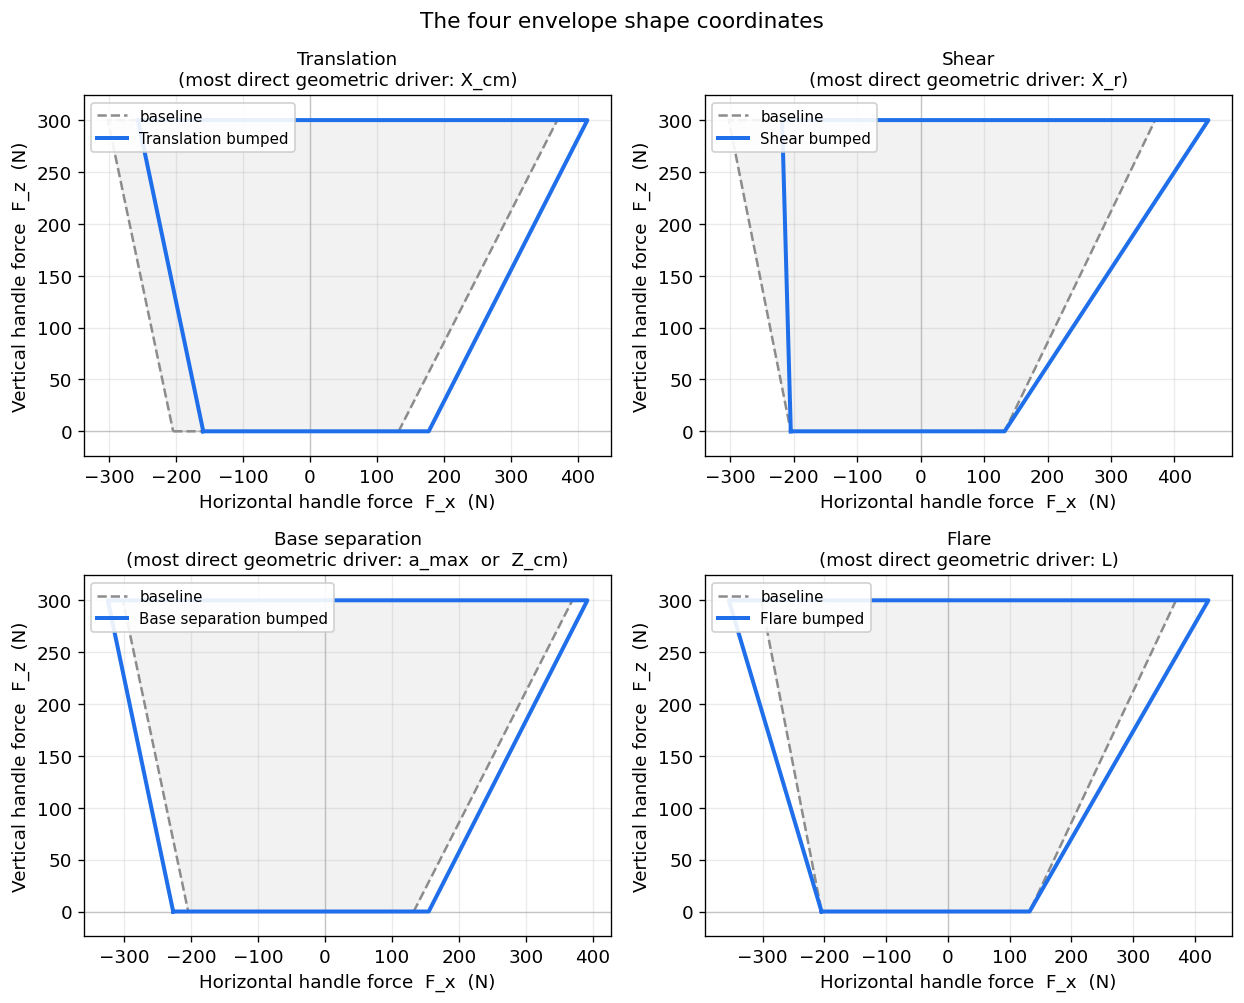

In [4]:
def trap_from_coords(T, S, B, F, Fzm):
    """Envelope trapezoid corners from the four shape coordinates.
       rear line : a_r = T + B/2 , b_r = S + F/2
       front line: a_f = T - B/2 , b_f = S - F/2   (corners at F_z = 0 and F_z = Fzm)"""
    a_r, b_r = T + B / 2.0, S + F / 2.0
    a_f, b_f = T - B / 2.0, S - F / 2.0
    xs = [a_f, a_r, a_r + b_r * Fzm, a_f + b_f * Fzm, a_f]
    ys = [0.0, 0.0, Fzm, Fzm, 0.0]
    return xs, ys


_Fzm  = BASE["Fz_max"]
_base = tuple(float(c) for c in shape_coords(BASE)[:4])   # (Translation, Shear, Base separation, Flare)

# panel:  (coordinate index, label, bumped value, most direct geometric driver)
PANELS = [
    (0, "Translation",     _base[0] + 45.0, "X_cm"),
    (1, "Shear",           _base[1] + 0.28, "X_r"),
    (2, "Base separation", _base[2] + 45.0, "a_max  or  Z_cm"),
    (3, "Flare",           _base[3] + 0.35, "L"),
]

fig, axes = plt.subplots(2, 2, figsize=(10.5, 8.5))
xb, yb = trap_from_coords(*_base, _Fzm)

for axm, (idx, coord_name, newval, driver) in zip(axes.flat, PANELS):
    c = list(_base); c[idx] = newval
    xp, yp = trap_from_coords(*c, _Fzm)

    axm.fill(xb, yb, color="0.5", alpha=0.10, zorder=1)
    axm.plot(xb, yb, "--", color="0.55", lw=1.5, label="baseline", zorder=2)
    axm.plot(xp, yp, "-",  color="#1f6feb", lw=2.4, label=f"{coord_name} bumped", zorder=3)

    axm.set_title(f"{coord_name}\n(most direct geometric driver: {driver})", fontsize=11)
    axm.set_xlabel("Horizontal handle force  F_x  (N)")
    axm.set_ylabel("Vertical handle force  F_z  (N)")
    axm.axhline(0, color="0.8", lw=0.8, zorder=0)
    axm.axvline(0, color="0.8", lw=0.8, zorder=0)
    axm.legend(loc="upper left", framealpha=0.9)
    axm.margins(y=0.08)

fig.suptitle("The four envelope shape coordinates", fontsize=13)
fig.tight_layout()
plt.show()

## 3. Sensitivity overview, which parameter moves which coordinate, and by how much

Every entry below is the partial derivative of a shape coordinate with respect to one
geometry parameter, read straight off the closed form in Section 1 (`theta = 0` except in
the `theta` row). A dash means that parameter does not appear in that coordinate at all.

| parameter | Translation | Shear | Base separation | Flare | how it scales |
|---|---|---|---|---|---|
| `X_cm`   | `+ m_r g cos(th) / H` | -- | -- | -- | linear (rigid shift) |
| `X_r`    | `- m_r g cos(th) / H` | `- 1 / H` | -- | -- | linear (slides the whole wheelbase under the handle) |
| `L`      | `- m_r g cos(th) / (2 H)` | `- 1 / (2 H)` | `+ m_r g cos(th) / H` | `+ 1 / H` | linear; **partials at fixed `X_r`** (X_f = X_r + L). Sweep 4.3 instead holds `X_r + L/2` at its baseline value (`-0.250` here), where the Translation & Shear terms cancel and only Base separation & Flare move |
| `Z_cm`   | `+ m_r g sin(th) / H`  (= 0 at th=0) | -- | `- 2 m_r a_max / H` | -- | linear |
| `H`      | `- Translation / H` | `- Shear / H` | `- Base separation / H` | `- Flare / H` | all four proportional to `1/H` |
| `theta`  | `m_r g [ Z_cm cos(th) - (X_cm - X_r - L/2) sin(th) ] / H` | -- | `- m_r g L sin(th) / H` | -- | trigonometric; both slopes stay `theta`-independent |
| `m_r`    | `Translation / m_r` | -- | `Base separation / m_r` | -- | both proportional to `m_r` |
| `c_rr`   | -- | -- | -- | -- | no effect here (`a_x` prescribed), enters only in the `F_drive = 0` note, 4.9 |
| `a_max`  | -- | -- | `- 2 m_r Z_cm / H` | -- | linear; the maneuvering-bound term. **`a_max` is PROVISIONAL** (1.5 m/s^2, pending sign-off) |


In [5]:
# Single source of truth for the analytical partials.
#   PARTIALS[param][coord] = (symbolic string, d(coord)/d(param) as a function of a param dict, scaling tag)
PARTIALS = {
    "X_cm": {
        "translation": ("m_r g cos(th) / H",
                        lambda p: p["m_r"] * p["g"] * np.cos(p["theta"]) / p["H"], "linear"),
    },
    "Xr": {
        "translation": ("- m_r g cos(th) / H",
                        lambda p: -p["m_r"] * p["g"] * np.cos(p["theta"]) / p["H"], "linear"),
        "shear":       ("- 1 / H",
                        lambda p: -1.0 / p["H"], "linear"),
    },
    "L": {
        "translation": ("- m_r g cos(th) / (2 H)",
                        lambda p: -p["m_r"] * p["g"] * np.cos(p["theta"]) / (2.0 * p["H"]), "linear"),
        "shear":       ("- 1 / (2 H)",
                        lambda p: -1.0 / (2.0 * p["H"]), "linear"),
        "separation":  ("m_r g cos(th) / H",
                        lambda p: p["m_r"] * p["g"] * np.cos(p["theta"]) / p["H"], "linear"),
        "flare":       ("1 / H",
                        lambda p: 1.0 / p["H"], "linear"),
    },
    "Z_cm": {
        "translation": ("m_r g sin(th) / H",
                        lambda p: p["m_r"] * p["g"] * np.sin(p["theta"]) / p["H"], "sin"),
        "separation":  ("- 2 m_r a_max / H",
                        lambda p: -2.0 * p["m_r"] * p["a_max"] / p["H"], "linear"),
    },
    "H": {
        "translation": ("- Translation / H", lambda p: -coords_closed_form(p)[0] / p["H"], "inverse"),
        "shear":       ("- Shear / H",       lambda p: -coords_closed_form(p)[1] / p["H"], "inverse"),
        "separation":  ("- Base separation / H", lambda p: -coords_closed_form(p)[2] / p["H"], "inverse"),
        "flare":       ("- Flare / H",       lambda p: -coords_closed_form(p)[3] / p["H"], "inverse"),
    },
    "theta": {
        "translation": ("m_r g [ Z_cm cos(th) - (X_cm - X_r - L/2) sin(th) ] / H",
                        lambda p: p["m_r"] * p["g"] * (p["Z_cm"] * np.cos(p["theta"])
                                  - (p["X_cm"] - p["Xr"] - p["L"] / 2.0) * np.sin(p["theta"])) / p["H"], "trig"),
        "separation":  ("- m_r g L sin(th) / H",
                        lambda p: -p["m_r"] * p["g"] * p["L"] * np.sin(p["theta"]) / p["H"], "sin"),
    },
    "m_r": {
        "translation": ("Translation / m_r", lambda p: coords_closed_form(p)[0] / p["m_r"], "prop"),
        "separation":  ("Base separation / m_r", lambda p: coords_closed_form(p)[2] / p["m_r"], "prop"),
    },
    "c_rr": {},
    "a_max": {
        "separation": ("- 2 m_r Z_cm / H",
                       lambda p: -2.0 * p["m_r"] * p["Z_cm"] / p["H"], "linear"),
    },
}

SCALE_NOTE = {"linear": "linear", "inverse": "proportional to 1/param",
              "trig": "trigonometric", "prop": "proportional to param", "sin": "carries sin(theta)"}

# symbolic grid
sym_grid = pd.DataFrame(index=list(PARTIALS), columns=[COORD_LABELS[k] for k in COORD_KEYS])
num_grid = pd.DataFrame(index=list(PARTIALS), columns=[COORD_LABELS[k] for k in COORD_KEYS], dtype=float)
for prm, d in PARTIALS.items():
    for k in COORD_KEYS:
        lbl = COORD_LABELS[k]
        if k in d:
            sym_grid.loc[prm, lbl] = d[k][0]
            num_grid.loc[prm, lbl] = d[k][1](BASE)
        else:
            sym_grid.loc[prm, lbl] = "--"
            num_grid.loc[prm, lbl] = 0.0

print("d(coordinate) / d(parameter), closed form:\n")
print(sym_grid.to_string())
print("\n\nd(coordinate) / d(parameter), evaluated at the CAD baseline (theta = 0;")
print(f"L={BASE['L']:g}, X_r={BASE['Xr']:g}, X_cm={BASE['X_cm']:g}, H={BASE['H']:g}, "
      f"Z_cm={BASE['Z_cm']:g}, m_r={BASE['m_r']:g};  {A_MAX_LABEL})")
print("units: coordinate per unit of the parameter (theta: per rad);  0.0 = parameter absent\n")
print(num_grid.to_string(float_format=lambda v: f"{v: .4g}"))
print("\nnote: Z_cm->Translation and theta->Base separation are 0 at the theta = 0 baseline")
print("      (both terms carry a sin(theta) factor); they become active on an incline.")
print("note: the L row is d/dL at FIXED X_r. Sweep 4.3 instead holds X_r + L/2 at its")
print("      baseline value; on that path the Translation and Shear terms cancel and")
print("      only Base separation and Flare move.")
print("note: any Base separation / Psi figure below inherits the PROVISIONAL a_max = 1.5 m/s^2.")

d(coordinate) / d(parameter), closed form:

                                                   Translation        Shear        Base separation        Flare
X_cm                                         m_r g cos(th) / H           --                     --           --
Xr                                         - m_r g cos(th) / H      - 1 / H                     --           --
L                                      - m_r g cos(th) / (2 H)  - 1 / (2 H)      m_r g cos(th) / H        1 / H
Z_cm                                         m_r g sin(th) / H           --      - 2 m_r a_max / H           --
H                                            - Translation / H  - Shear / H  - Base separation / H  - Flare / H
theta  m_r g [ Z_cm cos(th) - (X_cm - X_r - L/2) sin(th) ] / H           --  - m_r g L sin(th) / H           --
m_r                                          Translation / m_r           --  Base separation / m_r           --
c_rr                                                        

## 4. Parameter sweeps

Each parameter swept over a generous illustrative range (not tied to feasibility /
requirements ranges), everything else held at the CAD baseline (`L = 1.200`, `X_r = -0.850`,
`X_cm = -0.370`, `H = 1.075`, `Z_cm = 0.259840`, `m_r = 32.964`, `theta = 0`, `F_z,max = 300`;
`a_max = 1.5 m/s^2` still PROVISIONAL). Exception: the `L` sweep (4.3) scales the wheelbase
about the handle while holding `X_r + L/2` at its baseline value (`-0.250`, since the handle
no longer sits at the wheelbase midpoint here), so the handle's position relative to the
wheelbase doesn't drift as `L` changes.

Per parameter you get: the envelope figure (left, coloured by swept value), the shape
coordinates that actually move plotted numeric-vs-closed-form (right, should overlay), a
sensitivity readout, and the data table.


In [6]:
# The L sweep holds (X_r + L/2) at its baseline value, not at 0. generalized 2026-09-13
# At the old baseline (X_r=-0.400, L=0.800) that constant happened to be exactly 0 (handle
# at the wheelbase midpoint), which is why a hardcoded "X_r = -L/2" worked before. At this
# baseline (X_r=-0.850, L=1.200) the constant is X_r + L/2 = -0.250 (handle sits behind the
# wheelbase midpoint), so the coupling below must carry that offset explicitly or every L
# value off-baseline would silently use the wrong (old, symmetric) assumption.
_L_MIDPOINT_OFFSET = BASE["Xr"] + BASE["L"] / 2.0   # = -0.250 at this baseline

SWEEPS = {
    "X_cm":   dict(values=np.round(np.arange(-0.850, 0.350 + 1e-9, 0.01), 2), unit="m"),
    # 1 cm resolution, support-polygon bound X_r < X_cm < X_f at this baseline (X_r=-0.850, X_f=+0.350)
    "Xr":     dict(values=np.round(np.arange(-1.19, -0.80 + 1e-9, 0.01), 2), unit="m"),
    # 1 cm resolution, L=1.200 fixed -> X_f = X_r + 1.20 runs 0.01..0.40. Requested lower
    # bound was -1.20, but that makes X_f = 0.00 exactly, which fails check_geometry's
    # X_f > 0 requirement (front axle would sit exactly on the handle origin), clipped to
    # -1.19 (X_f = 0.01) to stay inside the tool's own validity bound; see the notebook note.
    "L":      dict(values=np.linspace(0.55, 1.30, 5),           unit="m",
                   couple=lambda L: {"Xr": _L_MIDPOINT_OFFSET - L / 2.0},
                   # requested lower bound was 0.49; with (X_r+L/2) pinned at -0.250 that
                   # requires L > 0.50 (else X_f = -0.250 + L/2 <= 0, invalid), clipped to
                   # 0.55 for a small safety margin (X_f = 0.025 m at that end); see the
                   # notebook note. If you'd rather hold X_r fixed at baseline for this sweep
                   # instead (dropping the "handle position preserved" coupling), 0.49 works
                   # as given too, can switch it if that's preferred
                   partials_path={                              # total d/dL along the coupled path (Translation & Shear cancel)
                       "separation": ("m_r g cos(th) / H",
                                      lambda p: p["m_r"] * p["g"] * np.cos(p["theta"]) / p["H"], "linear"),
                       "flare":      ("1 / H",
                                      lambda p: 1.0 / p["H"], "linear"),
                   }),
    "Z_cm":   dict(values=np.linspace( 0.05, 0.45, 5),          unit="m"),
    "H":      dict(values=np.linspace( 0.60, 1.60, 5),          unit="m"),
    "theta":  dict(values=np.deg2rad(np.linspace(-20, 20, 5)),  unit="deg", degrees=True),
    "m_r":    dict(values=np.linspace(10.0, 40.0, 5),           unit="kg"),
    "a_max":  dict(values=np.linspace( 0.0,  2.50, 5),          unit="m/s^2"),   # PROVISIONAL param
}


def _disp(spec):
    return np.rad2deg(spec["values"]) if spec.get("degrees") else spec["values"]


def _params_at(name, v):
    """BASE with `name` = v, plus any coupled-parameter rule for this sweep (e.g. L -> X_r via SWEEPS["L"]["couple"])."""
    p = dict(BASE, **{name: v})
    couple = SWEEPS[name].get("couple")
    if couple:
        p.update(couple(v))
    return p


def _coord_unit(k):
    return "N" if k in ("translation", "separation") else "N/N"


def _model_ctx(name):
    """Boundary / coordinate functions + partials for the prescribed-a_x model (Chapter 1)."""
    return dict(
        fx_r=lambda Fz, p: Fx_r(Fz, p, +p["a_max"]),
        fx_f=lambda Fz, p: Fx_f(Fz, p, -p["a_max"]),
        coords=shape_coords, closed=coords_closed_form,
        partials={**PARTIALS, name: SWEEPS[name].get("partials_path", PARTIALS[name])},
        label=None)


def _envelope_figure(name, spec, num, ctx):
    """
    Two-panel thesis figure:
      left  = the stability envelope across the sweep, viridis-coloured with a colourbar
               in the parameter's real units;
      right = one stacked sub-panel per moving shape coordinate: numeric envelope values
               (markers) vs the closed-form coordinate over the range (line).
    """
    vals  = spec["values"]
    disp  = np.asarray(_disp(spec), float)
    unit  = spec["unit"]
    plist = [_params_at(name, v) for v in vals]
    partials = ctx["partials"]

    # coordinates that the model's partials say depend on this parameter AND actually vary
    movers = [(k, COORD_KEYS.index(k)) for k in COORD_KEYS
              if k in partials[name]
              and float(num[:, COORD_KEYS.index(k)].max() - num[:, COORD_KEYS.index(k)].min()) > 1e-6]
    nmov = len(movers)
    moved_labels = [COORD_LABELS[k] for k, _ in movers]

    cmap = plt.cm.viridis
    norm = plt.Normalize(vmin=float(disp.min()), vmax=float(disp.max()))
    lcolors = cmap(norm(disp)) if disp.min() != disp.max() else cmap(np.full(len(disp), 0.5))

    nrows = max(nmov, 1)
    fig = plt.figure(figsize=(13.0, max(5.2, 2.35 * nrows + 0.8)), constrained_layout=True)
    gs  = fig.add_gridspec(nrows, 2, width_ratios=[1.35, 1.0])
    axL = fig.add_subplot(gs[:, 0])

    # left: envelope overlay
    Fz = np.linspace(0.0, BASE["Fz_max"], 80)
    for p, col in zip(plist, lcolors):
        axL.plot(ctx["fx_f"](Fz, p), Fz, color=col, lw=1.9, zorder=3)
        axL.plot(ctx["fx_r"](Fz, p), Fz, color=col, lw=1.9, zorder=3)

    sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap); sm.set_array([])
    # colourbar ticks: show every swept value for a short sweep, else a readable subset
    # (Xr / X_cm are now swept at 1 cm resolution, tens to ~120 points; the underlying
    # data is still the full-resolution array, only the tick LABELS are thinned)
    tick_vals = disp if len(disp) <= 9 else np.linspace(float(disp.min()), float(disp.max()), 7)
    cbar = fig.colorbar(sm, ax=axL, pad=0.02, ticks=tick_vals)
    cbar.ax.set_yticklabels([f"{d:g}" for d in tick_vals])
    cbar.set_label(f"{name}  ({unit})")

    box = (f"{name}: no effect on the envelope" if nmov == 0
           else f"moves: {', '.join(moved_labels)}")
    axL.text(0.03, 0.96, box, transform=axL.transAxes, va="top", ha="left",
             fontsize=9.5, bbox=dict(boxstyle="round", fc="white", ec="0.8"))
    axL.axhline(0, color="0.85", lw=0.8, zorder=0)
    axL.axvline(0, color="0.85", lw=0.8, zorder=0)
    axL.set_xlabel("Horizontal handle force  F_x  (N)")
    axL.set_ylabel("Vertical handle force  F_z  (N)")
    ttl = f"Stability envelope vs {name}"
    if ctx["label"]:
        ttl += f"\n{ctx['label']}"
    axL.set_title(ttl, fontsize=11)
    axL.margins(y=0.06)

    # right: coordinate vs parameter
    if nmov == 0:
        axR = fig.add_subplot(gs[:, 1]); axR.axis("off")
        axR.text(0.5, 0.5, f"No shape coordinate depends on {name}.",
                 ha="center", va="center", style="italic", fontsize=10)
        plt.show()
        return

    vd = np.linspace(float(np.min(vals)), float(np.max(vals)), 160)
    dd = np.rad2deg(vd) if spec.get("degrees") else vd
    cf = np.array([ctx["closed"](_params_at(name, v)) for v in vd])   # (160, 5)

    raxes = []
    for row, (k, i) in enumerate(movers):
        rax = fig.add_subplot(gs[row, 1], sharex=raxes[0] if raxes else None)
        raxes.append(rax)
        rax.plot(dd, cf[:, i], "-", color="#1f6feb", lw=1.8, label="closed form", zorder=2)
        rax.plot(disp, num[:, i], "o", color="k", ms=6, label="numeric", zorder=3)
        rax.set_ylabel(f"{COORD_LABELS[k]}\n({_coord_unit(k)})")
        rax.grid(alpha=0.25)
        if row == 0:
            rax.set_title("Shape coordinate vs parameter")
            rax.legend(loc="best", fontsize=8, framealpha=0.9)
        if row < nmov - 1:
            plt.setp(rax.get_xticklabels(), visible=False)
    raxes[-1].set_xlabel(f"{name}  ({unit})")

    plt.show()


def analyze_sweep(name):
    spec = SWEEPS[name]
    ctx  = _model_ctx(name)
    vals, disp, unit = spec["values"], _disp(spec), spec["unit"]
    plist = [_params_at(name, v) for v in vals]
    for p in plist:
        check_geometry(p)   # X_r < 0, L > 0, X_f = X_r + L > 0, raises on a bad sweep value
    num = np.array([ctx["coords"](p)  for p in plist])   # (5, 5)
    ana = np.array([ctx["closed"](p)  for p in plist])
    partials = ctx["partials"]

    _envelope_figure(name, spec, num, ctx)

    err = np.abs(num - ana) / (np.abs(ana) + 1.0)
    base_disp = np.rad2deg(BASE[name]) if spec.get("degrees") else BASE[name]
    print(f"parameter {name}: swept {disp.min():g} .. {disp.max():g} {unit}   (baseline {base_disp:g} {unit})")
    if name == "a_max":
        print("  a_max is a PROVISIONAL design spec, pending sign-off (not a measured value).")
    if name == "L":
        print(f"  swept with X_r + L/2 held at its baseline value ({_L_MIDPOINT_OFFSET:+.3f} m), "
              f"i.e. X_r = {_L_MIDPOINT_OFFSET:+.3f} - L/2;")
        print("  Translation and Shear stay pinned at their baseline values along this path, "
              "only Base separation and Flare move.")
    if ctx["label"]:
        print(f"  model: {ctx['label']}")
    print(f"  numeric envelope vs closed form: max error {err.max():.1e}  (the shape-coordinate identity holds)\n")

    du = "rad" if name == "theta" else ("unit" if unit == "-" else unit)
    for i, k in enumerate(COORD_KEYS):
        lbl = COORD_LABELS[k]
        col = num[:, i]
        if k in partials[name]:
            sym, fn, tag = partials[name][k]
            base_val = fn(BASE)
            if tag == "sin":
                print(f"  {lbl:16s} zero at theta = 0   d/d{name} = {sym}")
                print(f"  {'':16s}           (carries sin(theta), becomes active on an incline)")
            elif abs(base_val) < 1e-9:
                print(f"  {lbl:16s} unchanged here   d/d{name} = {sym}")
                print(f"  {'':16s}           (tracks {lbl}, which is ~0 at this baseline)")
            elif tag == "linear":
                s_num = np.polyfit(vals, col, 1)[0]
                match = abs(s_num - base_val) / (abs(base_val) + 1e-12)
                print(f"  {lbl:16s} MOVES     d/d{name} = {sym}")
                print(f"  {'':16s}           = {base_val:+.5g} per {du}   "
                      f"(numeric envelope slope {s_num:+.5g}, agree {match:.0e})")
            else:
                print(f"  {lbl:16s} MOVES     d/d{name} = {sym}   [{SCALE_NOTE[tag]}]")
                print(f"  {'':16s}           at baseline = {base_val:+.5g} per {du}   "
                      f"(closed form vs envelope: {err[:, i].max():.0e})")
        else:
            print(f"  {lbl:16s} unchanged (range over the sweep {col.max() - col.min():.1e})")

    psi = num[:, 4]
    psi_moves = abs(psi.max() - psi.min()) > 1e-6
    if name == "m_r":
        s_psi = np.polyfit(vals, psi, 1)[0]
        gL = BASE["g"] * BASE["L"] - 2 * BASE["Z_cm"] * BASE["a_max"]
        sign = "positive" if gL > 0 else "negative"
        print(f"  {'Psi':16s} moves     d(Psi)/dm_r = {s_psi:+.6g} N^2/kg  ({sign} at baseline; "
              f"sign flips when g L crosses 2 Z_cm a_max)")
    elif psi_moves:
        print(f"  {'Psi':16s} moves     range {psi.min():.6g} .. {psi.max():.6g} N^2")
    else:
        print(f"  {'Psi':16s} unchanged (range over the sweep {psi.max() - psi.min():.1e})")

    _cols = {f"{name} [{unit}]": disp}
    if spec.get("couple"):
        _cp = [spec["couple"](v) for v in vals]
        for _ck in _cp[0]:
            _clab = {"Xr": "X_r"}.get(_ck, _ck)
            _cols[f"{_clab} [m]"] = [d[_ck] for d in _cp]
    _cols.update({
        "Translation":     num[:, 0],
        "Shear":           num[:, 1],
        "Base separation": num[:, 2],
        "Flare":           num[:, 3],
        "Psi":             num[:, 4],
    })
    df = pd.DataFrame(_cols)
    if len(df) > 15:
        # Xr / X_cm are swept at 1 cm resolution (tens to ~120 rows), print an evenly
        # spaced sample (endpoints included) instead of dumping the whole table; the
        # returned df still carries every row.
        idx = np.unique(np.linspace(0, len(df) - 1, 11).round().astype(int))
        print(f"\n(showing {len(idx)} of {len(df)} swept points, evenly spaced; "
              f"the figure and checks above use the full resolution)")
        print(df.iloc[idx].to_string(index=False))
    else:
        print("\n" + df.to_string(index=False))
    return df

### 4.1  Sweep: `X_cm`

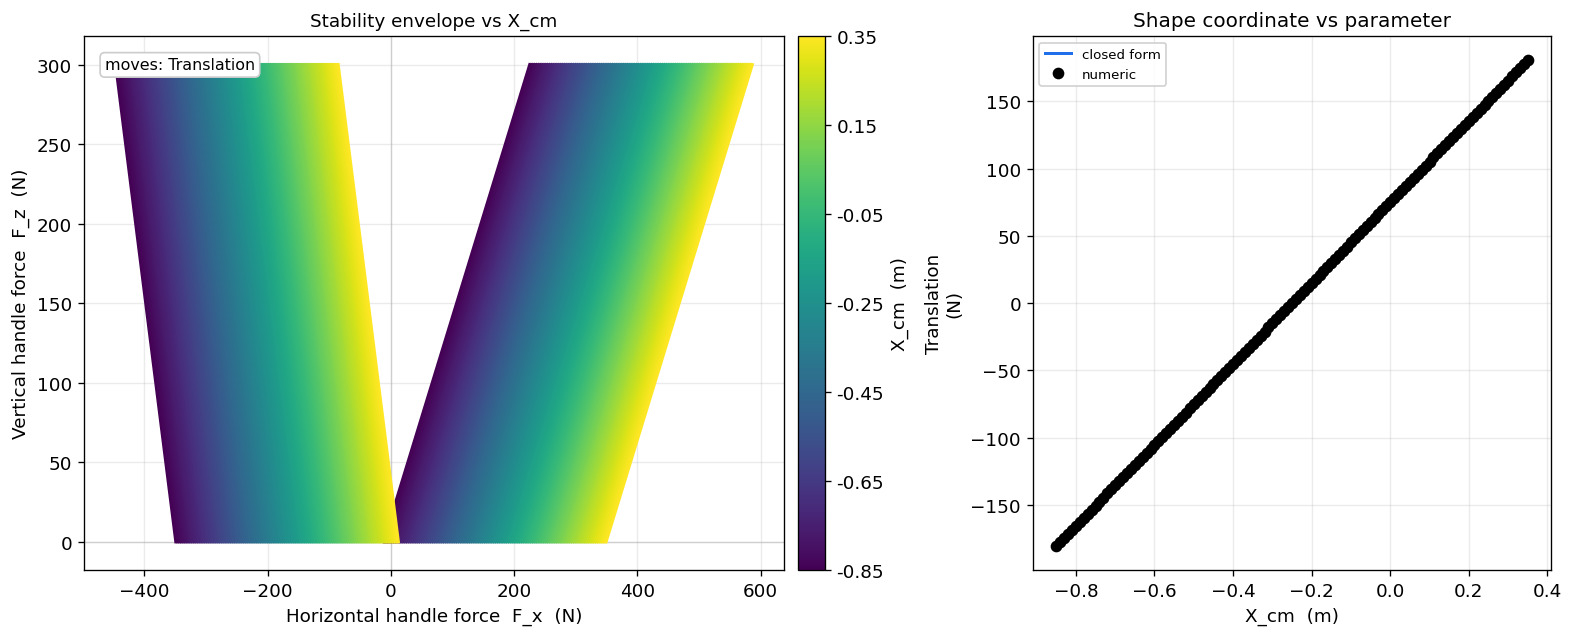

parameter X_cm: swept -0.85 .. 0.35 m   (baseline -0.37 m)
  numeric envelope vs closed form: max error 2.4e-14  (the shape-coordinate identity holds)

  Translation      MOVES     d/dX_cm = m_r g cos(th) / H
                             = +300.82 per m   (numeric envelope slope +300.82, agree 2e-16)
  Shear            unchanged (range over the sweep 5.0e-14)
  Base separation  unchanged (range over the sweep 1.1e-13)
  Flare            unchanged (range over the sweep 7.8e-14)
  Psi              unchanged (range over the sweep 3.6e-09)

(showing 11 of 121 swept points, evenly spaced; the figure and checks above use the full resolution)
 X_cm [m]  Translation     Shear  Base separation    Flare     Psi
    -0.85     -180.489  0.232558          337.075  1.11628  151355
    -0.73     -144.392  0.232558          337.075  1.11628  151355
    -0.61     -108.294  0.232558          337.075  1.11628  151355
    -0.49     -72.1958  0.232558          337.075  1.11628  151355
    -0.37     -36.097

In [7]:
_ = analyze_sweep("X_cm")

### 4.2  Sweep: `Xr`

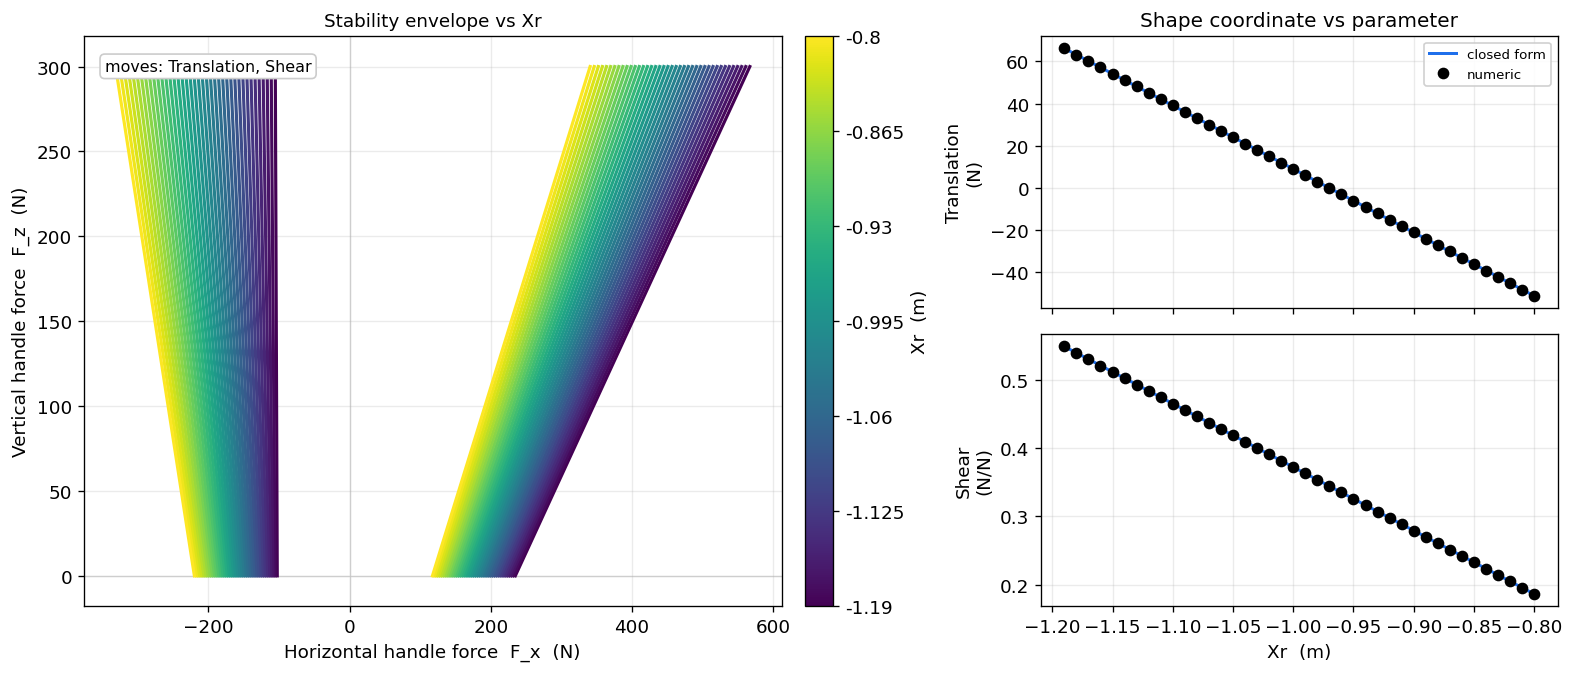

parameter Xr: swept -1.19 .. -0.8 m   (baseline -0.85 m)
  numeric envelope vs closed form: max error 2.0e-14  (the shape-coordinate identity holds)

  Translation      MOVES     d/dXr = - m_r g cos(th) / H
                             = -300.82 per m   (numeric envelope slope -300.82, agree 2e-15)
  Shear            MOVES     d/dXr = - 1 / H
                             = -0.93023 per m   (numeric envelope slope -0.93023, agree 8e-15)
  Base separation  unchanged (range over the sweep 5.7e-14)
  Flare            unchanged (range over the sweep 7.1e-14)
  Psi              unchanged (range over the sweep 3.2e-09)

(showing 11 of 40 swept points, evenly spaced; the figure and checks above use the full resolution)
 Xr [m]  Translation     Shear  Base separation    Flare     Psi
  -1.19      66.1794  0.548837          337.075  1.11628  151355
  -1.15      54.1468  0.511628          337.075  1.11628  151355
  -1.11      42.1142  0.474419          337.075  1.11628  151355
  -1.07      30.081

In [8]:
_ = analyze_sweep("Xr")

### 4.3  Sweep: `L`   (wheelbase length, handle's position relative to the wheelbase held fixed)


This sweep holds `X_r + L/2` at its baseline value (`-0.250` here, i.e. `X_r = -0.250 - L/2`) instead of holding `X_r` itself fixed. That isolates wheelbase *length* from the handle's fore/aft position within the wheelbase (the `X_r` sweep, 4.2), at this baseline the handle sits behind the wheelbase midpoint, so this isn't a left-right symmetric fan anymore. Section 3's `L` row lists the *partial* derivatives at fixed `X_r`; along this held-offset path the Translation and Shear contributions cancel, so only **Base separation** and **Flare** move and both tipping boundaries open up together.


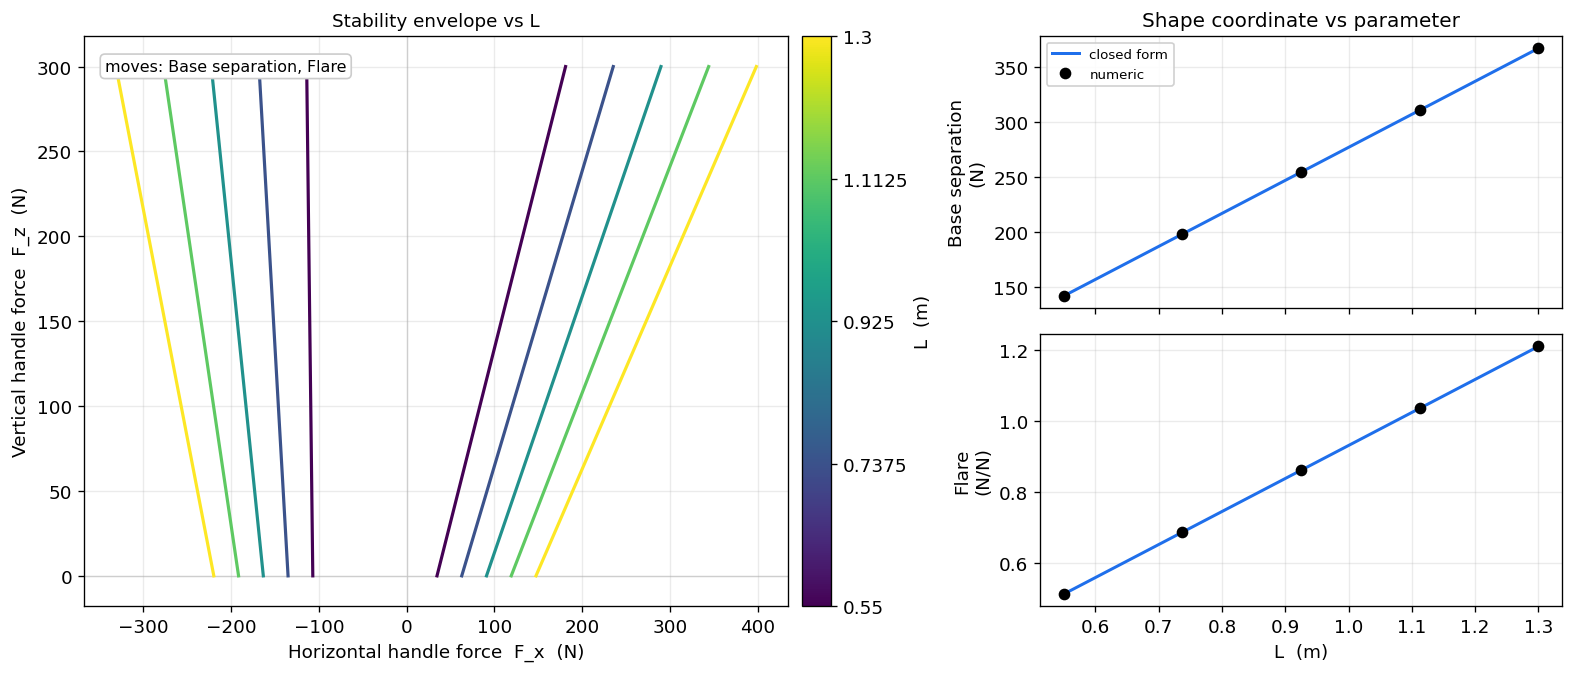

parameter L: swept 0.55 .. 1.3 m   (baseline 1.2 m)
  swept with X_r + L/2 held at its baseline value (-0.250 m), i.e. X_r = -0.250 - L/2;
  Translation and Shear stay pinned at their baseline values along this path, only Base separation and Flare move.
  numeric envelope vs closed form: max error 9.4e-15  (the shape-coordinate identity holds)

  Translation      unchanged (range over the sweep 7.1e-15)
  Shear            unchanged (range over the sweep 1.4e-14)
  Base separation  MOVES     d/dL = m_r g cos(th) / H
                             = +300.82 per m   (numeric envelope slope +300.82, agree 0e+00)
  Flare            MOVES     d/dL = 1 / H
                             = +0.93023 per m   (numeric envelope slope +0.93023, agree 4e-14)
  Psi              moves     range 65486.8 .. 164566 N^2

  L [m]  X_r [m]  Translation     Shear  Base separation     Flare      Psi
   0.55   -0.525     -36.0979  0.232558          141.545  0.511628  65486.8
 0.7375 -0.61875     -36.0979  0.232558

In [9]:
_ = analyze_sweep("L")

### 4.4  Sweep: `Z_cm`

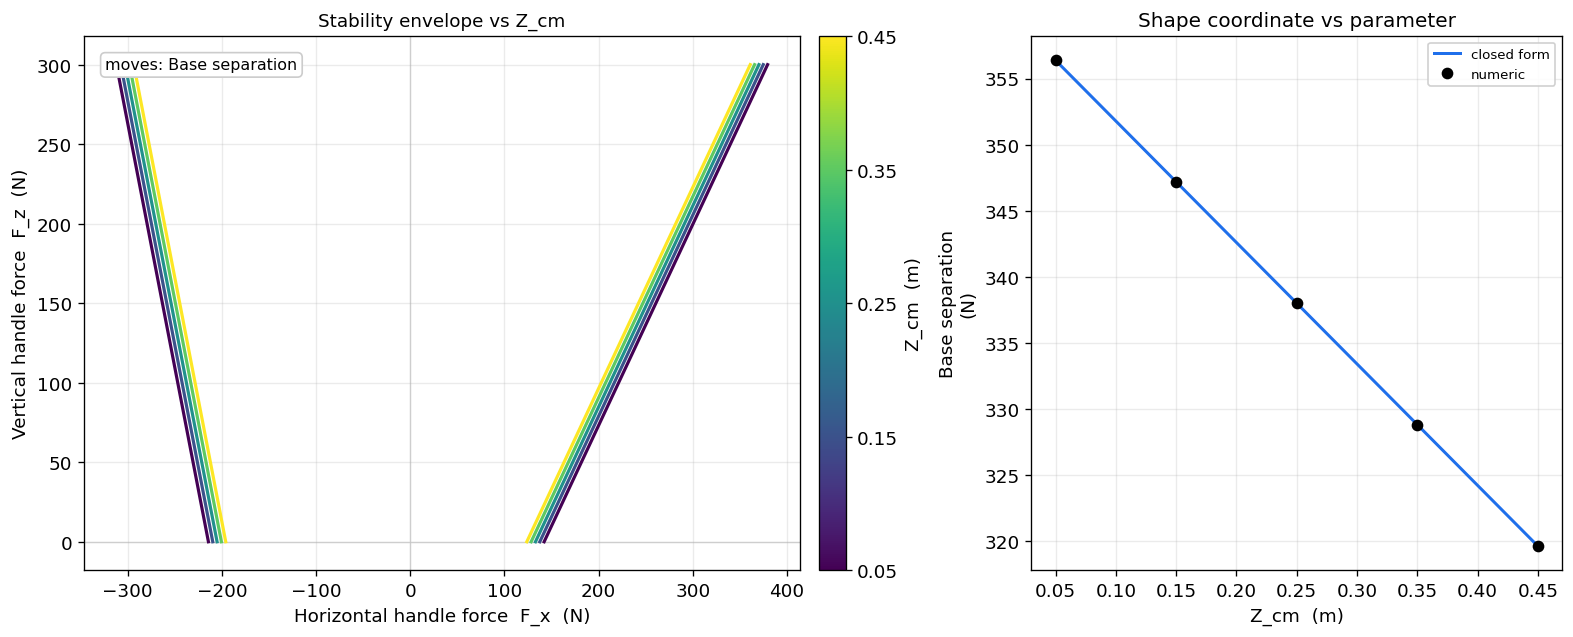

parameter Z_cm: swept 0.05 .. 0.45 m   (baseline 0.25984 m)
  numeric envelope vs closed form: max error 1.2e-14  (the shape-coordinate identity holds)

  Translation      zero at theta = 0   d/dZ_cm = m_r g sin(th) / H
                             (carries sin(theta), becomes active on an incline)
  Shear            unchanged (range over the sweep 1.4e-14)
  Base separation  MOVES     d/dZ_cm = - 2 m_r a_max / H
                             = -91.993 per m   (numeric envelope slope -91.993, agree 5e-15)
  Flare            unchanged (range over the sweep 2.8e-14)
  Psi              moves     range 146107 .. 157146 N^2

 Z_cm [m]  Translation     Shear  Base separation    Flare     Psi
     0.05     -36.0979  0.232558          356.379  1.11628  157146
     0.15     -36.0979  0.232558           347.18  1.11628  154387
     0.25     -36.0979  0.232558          337.981  1.11628  151627
     0.35     -36.0979  0.232558          328.781  1.11628  148867
     0.45     -36.0979  0.232558      

In [10]:
_ = analyze_sweep("Z_cm")

### 4.5  Sweep: `H`

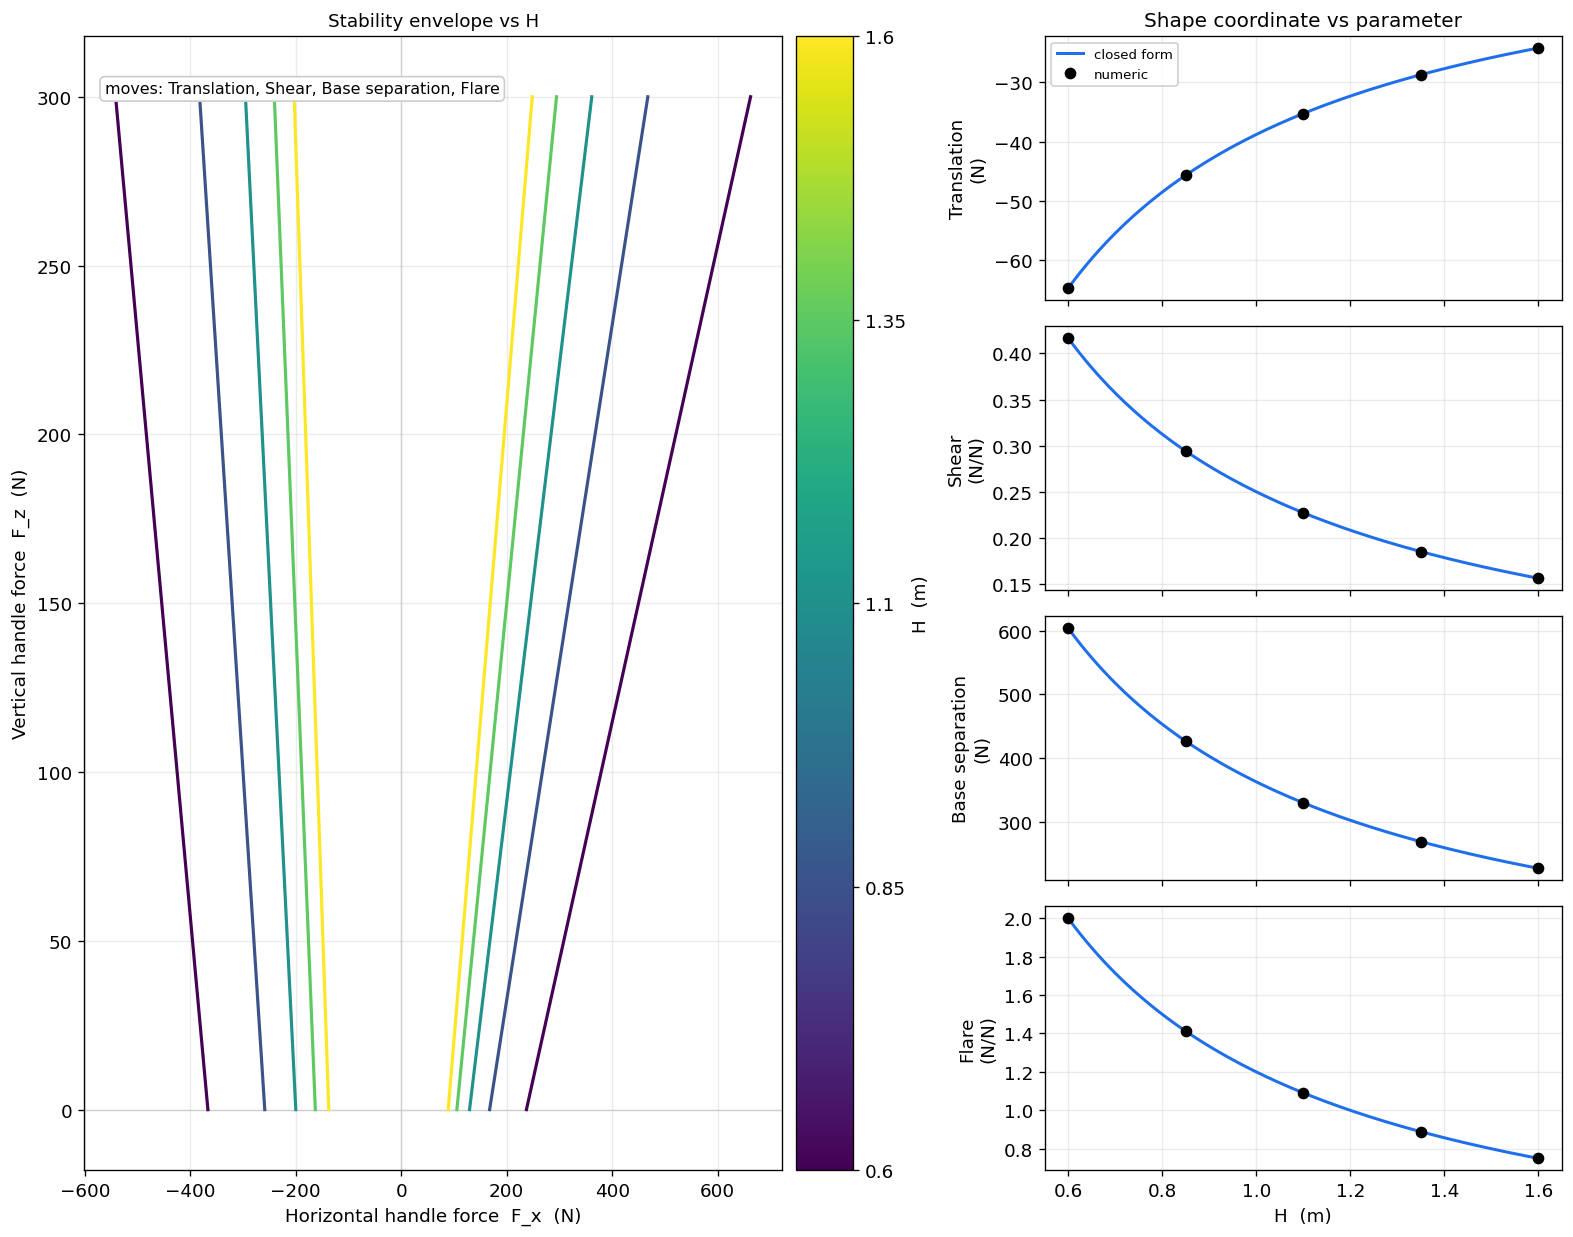

parameter H: swept 0.6 .. 1.6 m   (baseline 1.075 m)
  numeric envelope vs closed form: max error 9.7e-15  (the shape-coordinate identity holds)

  Translation      MOVES     d/dH = - Translation / H   [proportional to 1/param]
                             at baseline = +33.579 per m   (closed form vs envelope: 4e-16)
  Shear            MOVES     d/dH = - Shear / H   [proportional to 1/param]
                             at baseline = -0.21633 per m   (closed form vs envelope: 9e-15)
  Base separation  MOVES     d/dH = - Base separation / H   [proportional to 1/param]
                             at baseline = -313.56 per m   (closed form vs envelope: 2e-16)
  Flare            MOVES     d/dH = - Flare / H   [proportional to 1/param]
                             at baseline = -1.0384 per m   (closed form vs envelope: 1e-14)
  Psi              moves     range 101692 .. 271178 N^2

 H [m]  Translation     Shear  Base separation     Flare     Psi
   0.6     -64.6754  0.416667          603.

In [11]:
_ = analyze_sweep("H")

### 4.6  Sweep: `theta`

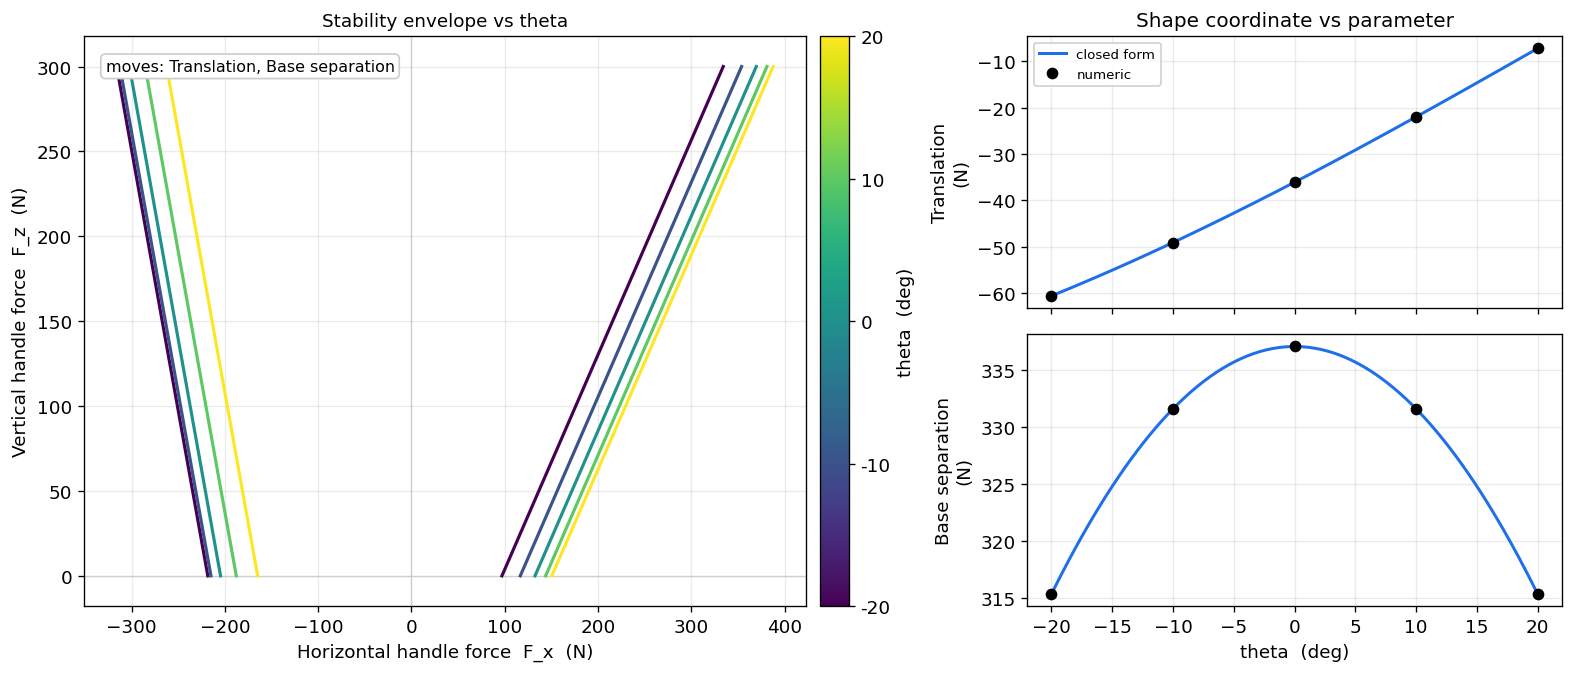

parameter theta: swept -20 .. 20 deg   (baseline 0 deg)
  numeric envelope vs closed form: max error 1.2e-14  (the shape-coordinate identity holds)

  Translation      MOVES     d/dtheta = m_r g [ Z_cm cos(th) - (X_cm - X_r - L/2) sin(th) ] / H   [trigonometric]
                             at baseline = +78.164 per rad   (closed form vs envelope: 1e-15)
  Shear            unchanged (range over the sweep 2.1e-14)
  Base separation  zero at theta = 0   d/dtheta = - m_r g L sin(th) / H
                             (carries sin(theta), becomes active on an incline)
  Flare            unchanged (range over the sweep 4.3e-14)
  Psi              moves     range 144824 .. 151355 N^2

 theta [deg]  Translation     Shear  Base separation    Flare     Psi
         -20     -60.6546  0.232558          315.306  1.11628  144824
         -10     -49.1225  0.232558          331.591  1.11628  149710
           0     -36.0979  0.232558          337.075  1.11628  151355
          10     -21.9764  0.23255

In [12]:
_ = analyze_sweep("theta")

### 4.7  Sweep: `m_r`

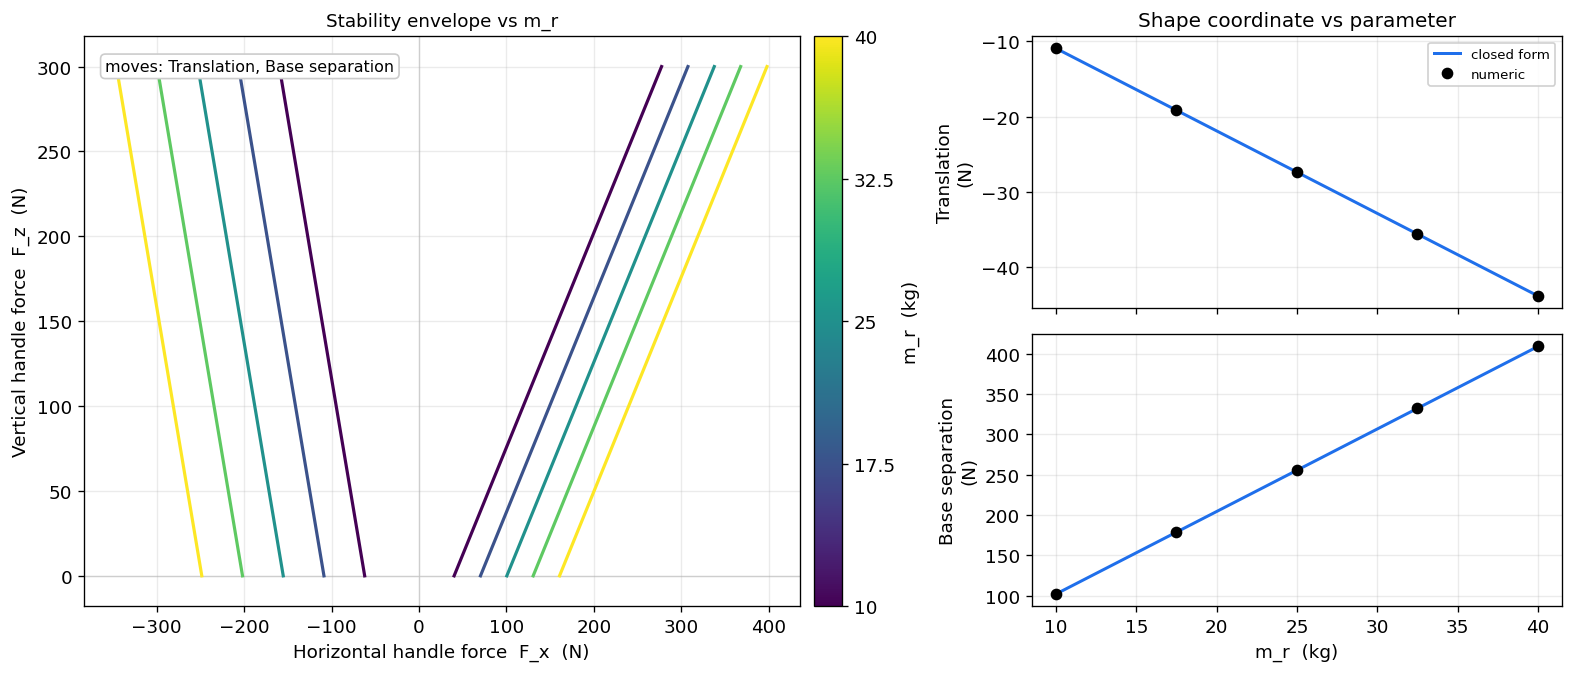

parameter m_r: swept 10 .. 40 kg   (baseline 32.964 kg)
  numeric envelope vs closed form: max error 2.0e-14  (the shape-coordinate identity holds)

  Translation      MOVES     d/dm_r = Translation / m_r   [proportional to param]
                             at baseline = -1.0951 per kg   (closed form vs envelope: 4e-16)
  Shear            unchanged (range over the sweep 2.8e-14)
  Base separation  MOVES     d/dm_r = Base separation / m_r   [proportional to param]
                             at baseline = +10.226 per kg   (closed form vs envelope: 2e-16)
  Flare            unchanged (range over the sweep 5.7e-14)
  Psi              moves     d(Psi)/dm_r = +3067.67 N^2/kg  (positive at baseline; sign flips when g L crosses 2 Z_cm a_max)

 m_r [kg]  Translation     Shear  Base separation    Flare      Psi
       10     -10.9507  0.232558          102.256  1.11628  80909.2
     17.5     -19.1637  0.232558          178.947  1.11628   103917
       25     -27.3767  0.232558          255.6

In [13]:
_ = analyze_sweep("m_r")

### 4.8  Sweep: `a_max`   (PROVISIONAL maneuvering-acceleration bound)

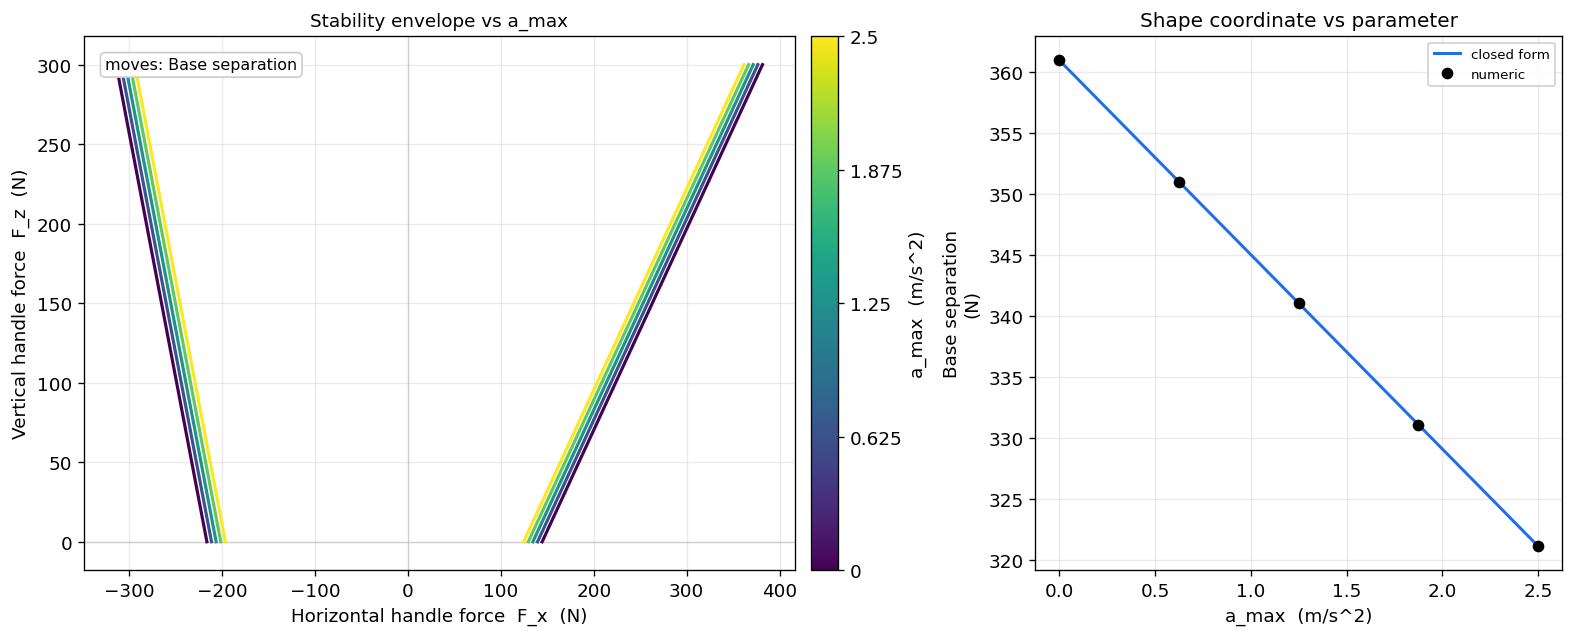

parameter a_max: swept 0 .. 2.5 m/s^2   (baseline 1.5 m/s^2)
  a_max is a PROVISIONAL design spec, pending sign-off (not a measured value).
  numeric envelope vs closed form: max error 1.5e-14  (the shape-coordinate identity holds)

  Translation      unchanged (range over the sweep 1.4e-14)
  Shear            unchanged (range over the sweep 2.8e-14)
  Base separation  MOVES     d/da_max = - 2 m_r Z_cm / H
                             = -15.936 per m/s^2   (numeric envelope slope -15.936, agree 5e-15)
  Flare            unchanged (range over the sweep 2.8e-14)
  Psi              moves     range 146575 .. 158526 N^2

 a_max [m/s^2]  Translation     Shear  Base separation    Flare     Psi
             0     -36.0979  0.232558          360.979  1.11628  158526
         0.625     -36.0979  0.232558          351.019  1.11628  155538
          1.25     -36.0979  0.232558          341.059  1.11628  152550
         1.875     -36.0979  0.232558            331.1  1.11628  149562
           2.5  

In [14]:
_ = analyze_sweep("a_max")

### 4.9  Rolling resistance  (`F_drive = 0`)

Side note in the Parameter Study chapter. Assumes **`F_drive = 0`** (no active propulsion
assistance): `a_x` is not prescribed, so eliminating it from the tipping-boundary moment
balance with the horizontal EOM `-F_x - c_rr (F_z + m_r g cosθ) + m_r g sinθ = m_r a_x`
(`a_x` left free before substitution) brings `c_rr` into the boundary, its slope and
intercept. `c_rr` is swept over **[0.005, 0.10]**, based on indicative caster-wheel rolling-
resistance literature (Table 1, `[cite source]`), this is a **proxy**, the device uses an
e-scooter wheel not a small hard caster, and no rollator/e-scooter-specific `c_rr`
measurement is available. Chapter 1 (prescribed `a_x`) is unaffected, `c_rr` is absent there
by construction.


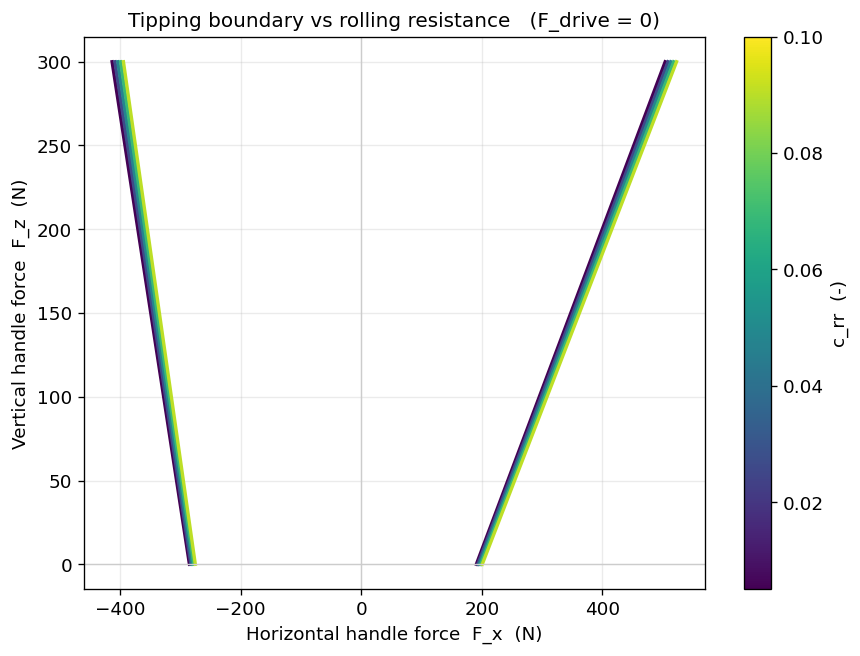

c_rr swept 0.005 .. 0.1  (F_drive = 0):
  the boundary translates by d(Translation)/d(c_rr) = +103.1 N per unit c_rr
  and shears by            d(Shear)/d(c_rr)       = +0.319 per unit c_rr
  (both are functions of m_r, g, theta, Z_cm, H only, independent of X_r/L, but
  DO move with m_r/Z_cm, so these numbers are specific to the current BASE)
  Base separation and Flare are algebraically unaffected (c_rr cancels).
  denominators clear of zero over the range:  X_r - c_rr Z_cm in [-0.876, -0.851],  X_f - c_rr Z_cm in [+0.324, +0.349].


In [15]:
# Rolling resistance, F_drive = 0.  Substitute m_r a_x = -F_x - c_rr (F_z + m_r g cos(th))
# + m_r g sin(th)  (thesis Eq. 11, a_x free) into the moment balance; sin(th) cancels.
# Boundary solved for F_x (denominator Z_cm - H; c_rr in slope and intercept):
def _Fx_bound_crr(Fz, p, Xb):
    mr, H, g, th, Zc, Xc, cr = (p["m_r"], p["H"], p["g"], p["theta"],
                                p["Z_cm"], p["X_cm"], p["c_rr"])
    return (Fz * (Xb - cr * Zc) - mr * g * np.cos(th) * (Xc - Xb + cr * Zc)) / (Zc - H)
# (checked once by hand: with the constant-velocity operating line, thesis Eq. 9/14,
#  substituted back in, this collapses to thesis Eq. 10 at theta = 0.)

_CRR_LO = 0.005
_CRR_HI = 0.10
_crr = np.linspace(_CRR_LO, _CRR_HI, 5)
_Fz  = np.linspace(0.0, BASE["Fz_max"], 80)
_Xr0, _Xf0 = _Xr_Xf(BASE)

fig, ax = plt.subplots(figsize=(7.4, 5.6))
_cols = plt.cm.viridis(np.linspace(0.0, 0.9, len(_crr)))
_T, _S = [], []
for _c, _col in zip(_crr, _cols):
    _p = dict(BASE, c_rr=_c)
    ax.plot(_Fx_bound_crr(_Fz, _p, _Xf0), _Fz, color=_col, lw=2.0)
    ax.plot(_Fx_bound_crr(_Fz, _p, _Xr0), _Fz, color=_col, lw=2.0)
    _ar, _af = _Fx_bound_crr(0.0, _p, _Xr0), _Fx_bound_crr(0.0, _p, _Xf0)
    _br = _Fx_bound_crr(1.0, _p, _Xr0) - _ar
    _bf = _Fx_bound_crr(1.0, _p, _Xf0) - _af
    _T.append(0.5 * (_ar + _af)); _S.append(0.5 * (_br + _bf))

_sm = plt.cm.ScalarMappable(norm=plt.Normalize(_CRR_LO, _CRR_HI), cmap="viridis"); _sm.set_array([])
fig.colorbar(_sm, ax=ax, label="c_rr  (-)")
ax.axhline(0, color="0.8", lw=0.8); ax.axvline(0, color="0.8", lw=0.8)
ax.set_xlabel("Horizontal handle force  F_x  (N)")
ax.set_ylabel("Vertical handle force  F_z  (N)")
ax.set_title("Tipping boundary vs rolling resistance   (F_drive = 0)")
ax.grid(alpha=0.25)
fig.tight_layout()
plt.show()

_dT = np.polyfit(_crr, _T, 1)[0]
_dS = np.polyfit(_crr, _S, 1)[0]
print(f"c_rr swept {_CRR_LO:g} .. {_CRR_HI:g}  (F_drive = 0):")
print(f"  the boundary translates by d(Translation)/d(c_rr) = {_dT:+.1f} N per unit c_rr")
print(f"  and shears by            d(Shear)/d(c_rr)       = {_dS:+.3f} per unit c_rr")
print(f"  (both are functions of m_r, g, theta, Z_cm, H only, independent of X_r/L, but")
print(f"  DO move with m_r/Z_cm, so these numbers are specific to the current BASE)")
print(f"  Base separation and Flare are algebraically unaffected (c_rr cancels).")
print(f"  denominators clear of zero over the range:  X_r - c_rr Z_cm in "
      f"[{_Xr0 - _CRR_HI*BASE['Z_cm']:+.3f}, {_Xr0 - _CRR_LO*BASE['Z_cm']:+.3f}],  "
      f"X_f - c_rr Z_cm in [{_Xf0 - _CRR_HI*BASE['Z_cm']:+.3f}, {_Xf0 - _CRR_LO*BASE['Z_cm']:+.3f}].")

## 5. Interactive envelope

Tune any parameter with the sliders and the prescribed-`a_x` stability envelope (Chapter 1)
redraws next to them. Sliders span each parameter's Section-4 sweep range, starting at the
CAD baseline (`L = 1.200`, `X_r = -0.850`, `X_cm = -0.370`, ...). `a_max` baseline 1.5 m/s^2
is still PROVISIONAL.

Current value of every parameter (plus derived `X_f = X_r + L`) is listed live below the
plot, anything moved off baseline gets highlighted with its delta. Reset button next to each
slider snaps that one back to baseline; reset all resets everything (ipywidgets doesn't have
a slider double-click event, hence the button instead).

Run the whole notebook first (VS Code: Run All at the top), this cell reuses `BASE`, the
boundary functions and `check_geometry` from Section 1.

If you just ran the install cell below, restart the kernel then Run All - a fresh
`pip install ipympl` isn't picked up until restart, without that you get `'widget' is not a
recognised backend name` and it falls back to a plain inline plot (works, just flickers on
redraw). With ipympl it's one persistent canvas, each slider move just moves the two lines.


In [16]:
# Run once, THEN RESTART THE KERNEL and Run All  (a fresh install is not seen until restart).
%pip install -q ipywidgets ipympl

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: C:\Users\Anura\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [17]:
import ipywidgets as W
from IPython.display import display, clear_output
from matplotlib.patches import Patch

# This cell depends on Sections 1-4 having run.
try:
    BASE, check_geometry, Fx_r, Fx_f, np, plt, SWEEPS, _disp
except NameError as _missing:
    raise NameError(
        "Run the notebook from the top first (VS Code: 'Run All'; or run Sections 1-4). "
        "This cell reuses BASE, the boundary functions, check_geometry and SWEEPS defined there."
    ) from _missing

# pick the best available matplotlib backend
try:
    _ip = get_ipython()
except NameError:
    _ip = None

_USE_IPYMPL = False
if _ip is not None:
    try:
        import ipympl  # noqa: F401
        _ip.run_line_magic("matplotlib", "widget")
        _USE_IPYMPL = True
    except Exception:
        _ip.run_line_magic("matplotlib", "inline")
        print("ipympl backend not active -> inline mode (redraws will flicker).")
        print("Fix: run the install cell above, then RESTART THE KERNEL and Run All.")

# palette (strong, theme-independent)
_C_BWD  = "#15489a"    # rear / backward-tipping boundary
_C_FWD  = "#c81e1e"    # front / forward-tipping boundary
_C_SAFE = "#1a9850"    # safe-region fill
_C_CHG  = "#2f7bf6"    # "value moved off baseline" accent (readable on light & dark)
_C_ERR  = "#e23b3b"

# sliders: ranges from the Section-4 SWEEPS dict, value = CAD baseline
_SLIDER_ORDER = ["X_cm", "Xr", "L", "Z_cm", "H", "theta", "m_r", "a_max"]
_GROUPS       = [("geometry", ["X_cm", "Xr", "L", "Z_cm", "H"]),
                 ("loading & dynamics", ["theta", "m_r", "a_max"])]
_FMT   = {"theta": ".1f", "m_r": ".1f", "a_max": ".2f"}
_LABEL = {"X_cm": "X_cm  (m)", "Xr": "X_r  (m)", "L": "L  (m)", "Z_cm": "Z_cm  (m)",
          "H": "H  (m)", "theta": "theta  (deg)", "m_r": "m_r  (kg)",
          "a_max": "a_max  (m/s^2)"}
_UNIT  = {"X_cm": "m", "Xr": "m", "L": "m", "Z_cm": "m", "H": "m",
          "theta": "deg", "m_r": "kg", "a_max": "m/s^2"}

def _base_disp(key):
    return float(np.rad2deg(BASE["theta"])) if key == "theta" else float(BASE[key])

_sliders = {}
for _k in _SLIDER_ORDER:
    _d = np.asarray(_disp(SWEEPS[_k]), float)
    _lo, _hi = round(float(_d.min()), 6), round(float(_d.max()), 6)
    _step = round((_hi - _lo) / 200.0, 4) or 0.001
    _sliders[_k] = W.FloatSlider(
        value=_base_disp(_k), min=_lo, max=_hi, step=_step, description=_LABEL[_k],
        readout_format=_FMT.get(_k, ".3f"), continuous_update=True,
        style={"description_width": "115px", "handle_color": _C_BWD},
        layout=W.Layout(width="330px"))

# reset controls (one click; ipywidgets has no slider double-click event)
def _reset_one(key):
    _sliders[key].value = _base_disp(key)

_reset_btns = {}
for _k in _SLIDER_ORDER:
    _b = W.Button(description="reset", tooltip=f"{_k}  ->  baseline {_base_disp(_k):g}",
                  layout=W.Layout(width="52px", min_width="52px"))
    _b.on_click(lambda _btn, k=_k: _reset_one(k))
    _reset_btns[_k] = _b

_reset_all = W.Button(description="reset all", button_style="warning",
                      tooltip="every slider back to baseline",
                      layout=W.Layout(width="140px"))
def _reset_all_fn(_btn):
    for k in _SLIDER_ORDER:
        _reset_one(k)
_reset_all.on_click(_reset_all_fn)

def _hdr(txt):
    return W.HTML(f"<div style='font-weight:700;font-size:10.5px;letter-spacing:.07em;"
                  f"text-transform:uppercase;opacity:.6;margin:13px 0 1px'>{txt}</div>")

_slider_rows = {_k: W.HBox([_sliders[_k], _reset_btns[_k]],
                           layout=W.Layout(align_items="center")) for _k in _SLIDER_ORDER}

_control_col = W.VBox(
    [W.HTML("<div style='font-weight:700;font-size:14px'>Interactive stability envelope</div>"
            "<div style='font-size:11px;opacity:.7;margin-top:1px'>"
            "drag a slider &rarr; the envelope redraws.  "
            "<b>reset</b> next to a slider sends that parameter to baseline.</div>"),
     _hdr(_GROUPS[0][0])] + [_slider_rows[k] for k in _GROUPS[0][1]] +
    [_hdr(_GROUPS[1][0])] + [_slider_rows[k] for k in _GROUPS[1][1]] +
    [W.HTML("<div style='height:10px'></div>"), _reset_all],
    layout=W.Layout(padding="2px 14px 2px 2px"))

# live readout: every parameter's value; anything off baseline is highlighted
_readout = W.HTML()

def _readout_html(p):
    Xf = p["Xr"] + p["L"]

    def row(name, val, base, unit, fmt, tag=""):
        moved = abs(val - base) > 1e-9
        val_s = (f"{val:{fmt}}" + (f" {unit}" if unit else "")).strip()
        col   = _C_CHG if moved else "inherit"
        wt    = "700"  if moved else "500"
        delta = (f"<span style='color:{_C_CHG};opacity:.85;font-size:11px'>"
                 f"&Delta; {val - base:+.3g}</span>") if moved else ""
        return (f"<tr>"
                f"<td style='padding:2px 14px 2px 0;opacity:.65'>{name}</td>"
                f"<td style='padding:2px 12px 2px 0;text-align:right;"
                f"font-weight:{wt};color:{col}'>{val_s}</td>"
                f"<td style='padding:2px 0'>{delta}{tag}</td></tr>")

    geo = "".join(row(n, p[k], _base_disp(k), _UNIT[k], _FMT.get(k, ".3f"))
                  for n, k in [("X_cm", "X_cm"), ("X_r", "Xr"), ("L", "L"),
                               ("Z_cm", "Z_cm"), ("H", "H")])
    xf_tag = "" if Xf > 0 else f"<span style='color:{_C_ERR};font-weight:700'>&nbsp;invalid: X_f &le; 0</span>"
    xf_row = (f"<tr><td colspan='3' style='border-top:1px solid rgba(128,128,128,.3);"
              f"height:5px'></td></tr>"
              f"<tr><td style='padding:2px 14px 2px 0;opacity:.65'>&rarr; X_f = X_r + L</td>"
              f"<td style='padding:2px 12px 2px 0;text-align:right;font-weight:700'>"
              f"{Xf:+.3f} m</td><td>{xf_tag}</td></tr>"
              f"<tr><td colspan='3' style='height:7px'></td></tr>")
    dyn = (row("theta", np.rad2deg(p["theta"]), _base_disp("theta"), "deg", "+.1f")
           + row("m_r", p["m_r"], _base_disp("m_r"), "kg", ".2f")
           + row("a_max", p["a_max"], _base_disp("a_max"), "m/s^2", ".2f",
                 "<span style='opacity:.45'>&nbsp;PROVISIONAL</span>"))
    fzmax = (f"<tr><td colspan='3' style='height:7px'></td></tr>"
             f"<tr><td style='padding:2px 14px 2px 0;opacity:.65'>F_z,max</td>"
             f"<td style='padding:2px 12px 2px 0;text-align:right;opacity:.75'>"
             f"{p['Fz_max']:.0f} N</td><td></td></tr>")

    return (f"<div style='font-family:ui-monospace,SFMono-Regular,Consolas,monospace;"
            f"font-size:12.5px;line-height:1.4;display:inline-block;"
            f"border:1px solid rgba(128,128,128,.35);border-radius:8px;"
            f"padding:9px 15px;background:rgba(128,128,128,.05);margin-top:10px'>"
            f"<div style='font-weight:700;font-size:11px;letter-spacing:.05em;"
            f"text-transform:uppercase;opacity:.7;margin-bottom:5px'>current parameters"
            f"&nbsp;&nbsp;<span style='text-transform:none;letter-spacing:0;opacity:.75'>"
            f"prescribed a_x  (Ch. 1)</span></div>"
            f"<table style='border-collapse:collapse'>{geo}{xf_row}{dyn}{fzmax}</table></div>")

# one persistent, high-contrast figure
plt.ioff()
with plt.rc_context({"axes.edgecolor": "#3a3a3a", "axes.linewidth": 1.3,
                     "xtick.color": "#3a3a3a", "ytick.color": "#3a3a3a",
                     "xtick.labelsize": 11, "ytick.labelsize": 11}):
    _fig, _ax = plt.subplots(figsize=(7.6, 6.0))
_fig.patch.set_facecolor("white")
_ax.set_facecolor("white")
if _USE_IPYMPL:
    _fig.canvas.header_visible   = False
    _fig.canvas.footer_visible   = True          # hover -> read off F_x, F_z
    _fig.canvas.toolbar_position = "bottom"

_out = W.Output()
_Fz = np.linspace(0.0, BASE["Fz_max"], 240)
(_line_r,) = _ax.plot([], [], "-", color=_C_BWD, lw=3.0, solid_capstyle="round",
                      label="rear (backward tipping)")
(_line_f,) = _ax.plot([], [], "-", color=_C_FWD, lw=3.0, solid_capstyle="round",
                      label="front (forward tipping)")
_fill_ref = [None]
_msg = _ax.text(0.5, 0.5, "", transform=_ax.transAxes, ha="center", va="center",
                fontsize=13, fontweight="bold", color=_C_ERR, zorder=6,
                bbox=dict(boxstyle="round,pad=0.55", fc="#fdeaea", ec=_C_ERR, lw=1.3))
_msg.set_visible(False)
_ax.axhline(0, color="#5a5a5a", lw=1.1, zorder=1)
_ax.axvline(0, color="#5a5a5a", lw=1.1, zorder=1)
_ax.set_xlim(-400, 750)   # covers each slider's single-parameter extreme at this baseline
_ax.set_ylim(-60, 340)    # F_z axis unaffected by the Xr/L baseline (always swept 0..Fz_max)
_ax.set_xlabel("Horizontal handle force  F_x  (N)", fontsize=12.5, color="#1e1e1e")
_ax.set_ylabel("Vertical handle force  F_z  (N)", fontsize=12.5, color="#1e1e1e")
_ax.grid(True, color="#d5d5d5", lw=0.8)
_ax.set_axisbelow(True)
_ax.legend(handles=[_line_r, _line_f,
                    Patch(facecolor=_C_SAFE, alpha=0.16, label="safe region")],
           loc="lower left", fontsize=10.5, frameon=True, facecolor="white",
           edgecolor="#bbb", framealpha=0.96)
_fig.tight_layout()

def _draw(*_):
    p = dict(BASE)
    for key, s in _sliders.items():
        p[key] = s.value
    p["theta"] = float(np.deg2rad(_sliders["theta"].value))

    if _fill_ref[0] is not None:
        _fill_ref[0].remove()
        _fill_ref[0] = None
    try:
        check_geometry(p)
        x_r, x_f = Fx_r(_Fz, p, +p["a_max"]), Fx_f(_Fz, p, -p["a_max"])
        sub = f"prescribed a_x, rear +{p['a_max']:.2f}, front -{p['a_max']:.2f} m/s^2  (PROVISIONAL)"
        _line_r.set_data(x_r, _Fz)
        _line_f.set_data(x_f, _Fz)
        _fill_ref[0] = _ax.fill_betweenx(_Fz, x_f, x_r, where=(x_r >= x_f),
                                         color=_C_SAFE, alpha=0.16, zorder=0)
        _msg.set_visible(False)
        _ax.set_title("Stability envelope\n" + sub,
                      fontsize=12.5, fontweight="bold", color="#141414", pad=9)
    except ValueError:
        _line_r.set_data([], [])
        _line_f.set_data([], [])
        _msg.set_text(f"invalid geometry\nX_f = X_r + L = {p['Xr'] + p['L']:+.2f} m   (must be > 0)")
        _msg.set_visible(True)
        _ax.set_title("Stability envelope", fontsize=12.5, fontweight="bold",
                      color="#141414", pad=9)
    _readout.value = _readout_html(p)
    _fig.canvas.draw_idle()
    if not _USE_IPYMPL:                 # inline fallback: reshow the same figure, old frame kept
        with _out:
            clear_output(wait=True)
            display(_fig)

for _s in _sliders.values():
    _s.observe(_draw, "value")
_draw()

_plot_view = _fig.canvas if _USE_IPYMPL else _out
display(W.HBox([_control_col, W.VBox([_plot_view, _readout])],
               layout=W.Layout(align_items="flex-start")))

## 6. Quantified sensitivity - marginal value of a design change (Psi)

Section 3 has the closed-form partials of the four shape coordinates. This turns the ones
that matter for dynamic stability capacity Psi into a concrete "change this parameter by
this much, Psi moves by this many N^2 / this many %", evaluated at the current CAD baseline.

Psi = (Base separation)*F_z,max + 1/2*(Flare)*F_z,max^2, and neither Base separation nor
Flare contains `X_r` or `X_cm` (only Translation and Shear do) - so `X_r` and `X_cm` have
exactly zero effect on Psi. Moving the CoM fore/aft or relocating the rear axle shifts where
the safe operating region sits, not its size. Excluded below for that reason, not because the
effect happens to be small. `theta` is excluded because its effect on Psi is exactly zero at
this design's level-ground baseline and incline operation isn't in scope. `c_rr` is excluded
because it's absent from this prescribed-`a_x` model by construction (separately confirmed
not to touch Base separation/Flare even in the F_drive=0 note, 4.9).

That leaves `m_r`, `L`, `Z_cm`, `a_max`, for which Psi turns out to be exactly affine, not
just locally linear - each one's marginal rate is a genuine constant over the whole sweep
range, checked below against a step 1000x smaller. `H` is the exception, Psi is proportional
to 1/H exactly, so a single per-cm rate would be misleading; reported instead as the exact
Psi at the Front Open handle-height requirement's two endpoints (0.95 m / 1.20 m).

Step sizes used (one plausible design revision per parameter): `m_r` +1 kg, `L` +1 cm,
`Z_cm` +1 cm, `a_max` +0.1 m/s^2 (still PROVISIONAL).


In [18]:
def _psi_at(**overrides):
    return coords_closed_form(dict(BASE, **overrides))[4]

PSI_BASE = _psi_at()
print(f"Baseline Psi = {PSI_BASE:.1f} N^2   (L={BASE['L']:g}, X_r={BASE['Xr']:g}, "
      f"X_cm={BASE['X_cm']:g}, Z_cm={BASE['Z_cm']:g}, H={BASE['H']:g}, m_r={BASE['m_r']:g}, "
      f"theta={BASE['theta']:g}, a_max={BASE['a_max']:g})\n")

STEPS      = {"m_r": 1.0, "L": 0.01, "Z_cm": 0.01, "a_max": 0.1}
STEP_UNIT  = {"m_r": "kg", "L": "m", "Z_cm": "m", "a_max": "m/s^2"}
STEP_LABEL = {"m_r": "mass m_r", "L": "wheelbase length L", "Z_cm": "CoM height Z_cm",
              "a_max": "maneuvering bound a_max"}

_rows = []
for k, step in STEPS.items():
    d_psi = _psi_at(**{k: BASE[k] + step}) - PSI_BASE
    # exactness check: Psi should be affine in k, so the per-unit rate from a step 1000x
    # smaller (rescaled) must match the rate from the requested step to machine precision
    d_psi_tiny = (_psi_at(**{k: BASE[k] + step / 1000.0}) - PSI_BASE) * 1000.0
    is_affine = abs(d_psi - d_psi_tiny) < 1e-6 * max(abs(d_psi), 1.0)
    pct = d_psi / PSI_BASE * 100.0
    verb = "increases" if d_psi > 0 else "decreases"
    tag  = "exact, affine in this parameter, holds over the full sweep range" if is_affine \
           else "local approximation near baseline only"
    print(f"+{step:g} {STEP_UNIT[k]:6s} of {STEP_LABEL[k]:24s} -> Psi {verb} by "
          f"{abs(d_psi):8.1f} N^2  ({pct:+.3f} %)   [{tag}]")
    _rows.append(dict(parameter=k, step=step, unit=STEP_UNIT[k],
                       delta_Psi_N2=d_psi, delta_Psi_pct=pct))

print("\n" + pd.DataFrame(_rows).to_string(index=False))

Baseline Psi = 151355.2 N^2   (L=1.2, X_r=-0.85, X_cm=-0.37, Z_cm=0.25984, H=1.075, m_r=32.964, theta=0, a_max=1.5)

+1 kg     of mass m_r                 -> Psi increases by   3067.7 N^2  (+2.027 %)   [exact, affine in this parameter, holds over the full sweep range]
+0.01 m      of wheelbase length L       -> Psi increases by   1321.1 N^2  (+0.873 %)   [exact, affine in this parameter, holds over the full sweep range]
+0.01 m      of CoM height Z_cm          -> Psi decreases by    276.0 N^2  (-0.182 %)   [exact, affine in this parameter, holds over the full sweep range]
+0.1 m/s^2  of maneuvering bound a_max  -> Psi decreases by    478.1 N^2  (-0.316 %)   [exact, affine in this parameter, holds over the full sweep range]

parameter  step  unit  delta_Psi_N2  delta_Psi_pct
      m_r     1    kg       3067.67         2.0268
        L  0.01     m       1321.05       0.872816
     Z_cm  0.01     m      -275.978      -0.182338
    a_max   0.1 m/s^2      -478.067      -0.315858


In [19]:
# H: Psi is exactly proportional to 1/H (not locally linear), report the Front Open
# handle-height requirement's endpoints directly instead of a per-cm marginal rate.
H_LO, H_HI = 0.95, 1.20   # Front Open handle-height range (elbow-height criterion, stature 150-191cm)
psi_hlo, psi_hhi = _psi_at(H=H_LO), _psi_at(H=H_HI)
print(f"Handle height H (Front Open range {H_LO:.2f}-{H_HI:.2f} m), Psi is proportional")
print(f"to 1/H, so no single per-cm rate is representative; the two endpoints:")
print(f"  H = {H_LO:.2f} m (lowest setting) :  Psi = {psi_hlo:8.1f} N^2")
print(f"  H = {BASE['H']:.3f} m (baseline)     :  Psi = {PSI_BASE:8.1f} N^2")
print(f"  H = {H_HI:.2f} m (highest setting):  Psi = {psi_hhi:8.1f} N^2")
print(f"  lowest vs highest setting: Psi changes by {psi_hlo - psi_hhi:+.1f} N^2 "
      f"({(psi_hlo - psi_hhi) / psi_hhi * 100:+.1f} % relative to the highest-setting value)")

print("\nExcluded from the table above:")
print(f"  X_r, X_cm: structurally absent from Psi (verified: {_psi_at(Xr=BASE['Xr']+0.05)-PSI_BASE:.2e},")
print(f"              {_psi_at(X_cm=BASE['X_cm']+0.05)-PSI_BASE:.2e} N^2 for a +5 cm nudge, exactly 0)")
print(f"  theta     : zero effect on Psi at this level-ground baseline (theta = 0), out of scope")
print(f"  c_rr      : absent from this model by construction (see 4.9 for the separate proof)")

Handle height H (Front Open range 0.95-1.20 m), Psi is proportional
to 1/H, so no single per-cm rate is representative; the two endpoints:
  H = 0.95 m (lowest setting) :  Psi = 171270.4 N^2
  H = 1.075 m (baseline)     :  Psi = 151355.2 N^2
  H = 1.20 m (highest setting):  Psi = 135589.0 N^2
  lowest vs highest setting: Psi changes by +35681.3 N^2 (+26.3 % relative to the highest-setting value)

Excluded from the table above:
  X_r, X_cm: structurally absent from Psi (verified: 0.00e+00,
              0.00e+00 N^2 for a +5 cm nudge, exactly 0)
  theta     : zero effect on Psi at this level-ground baseline (theta = 0), out of scope
  c_rr      : absent from this model by construction (see 4.9 for the separate proof)
